# Complete Movies Dataset Analysis
**CCS3522 – Data Science | Movies Dataset**

This notebook combines all analysis steps into a single comprehensive workflow:
1. **Initial Data Exploration** - Understanding the dataset structure and distributions
2. **Data Preprocessing Pipeline** - Cleaning, feature engineering, and preparation
3. **Regression Preparation** - Encoding and scaling for regression models
4. **Relationships and Regression Analysis** - Statistical analysis and modeling

---


## Part 1: Initial Data Exploration

This section provides an overview of the dataset structure, distributions, and initial observations that will guide the preprocessing stage.


In [1]:
# Import libraries and load the dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv('movies.csv')
data = df.copy()

### 1.1 Dataset Overview and Basic Information


In [2]:
# Check the dimensions of the dataset
data.shape

(63000, 15)

In [3]:
# Check all of the columns of the dataset
data.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'budget', 'original_language', 'popularity',
       'genres', 'production_companies', 'production_countries',
       'spoken_languages'],
      dtype='object')

In [4]:
# Get more information about the variables of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63000 entries, 0 to 62999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    63000 non-null  int64  
 1   title                 63000 non-null  object 
 2   vote_average          63000 non-null  float64
 3   vote_count            63000 non-null  int64  
 4   status                63000 non-null  object 
 5   release_date          62973 non-null  object 
 6   revenue               63000 non-null  int64  
 7   runtime               63000 non-null  int64  
 8   budget                63000 non-null  int64  
 9   original_language     63000 non-null  object 
 10  popularity            63000 non-null  float64
 11  genres                62517 non-null  object 
 12  production_companies  56870 non-null  object 
 13  production_countries  60859 non-null  object 
 14  spoken_languages      62046 non-null  object 
dtypes: float64(2), int6

### 1.2 Missing Values Analysis


In [5]:
# Check the null values in each column 
data.isna().sum().sort_values(ascending=False)

production_companies    6130
production_countries    2141
spoken_languages         954
genres                   483
release_date              27
title                      0
id                         0
revenue                    0
status                     0
vote_count                 0
vote_average               0
popularity                 0
original_language          0
budget                     0
runtime                    0
dtype: int64

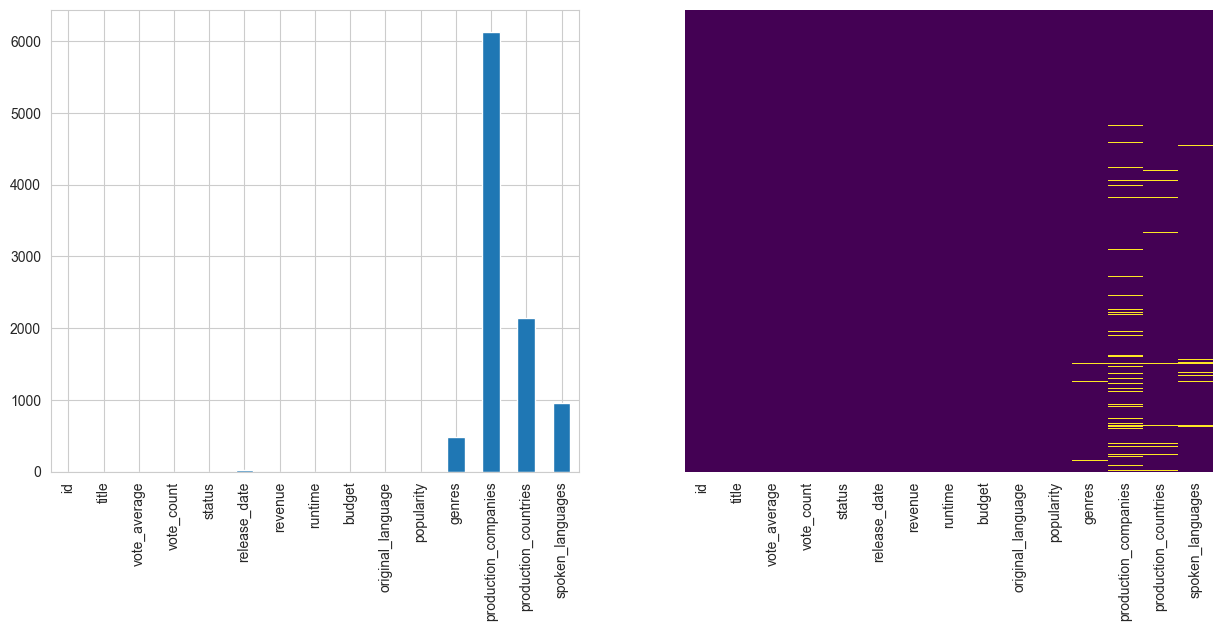

In [6]:
# Visualize missing values with bar and heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
data.isna().sum().plot(kind='bar', ax=ax1)
sns.heatmap(data.isnull(),yticklabels=False, cbar=False, cmap='viridis',ax=ax2)
plt.show()

### 1.3 Numerical Variable Distributions


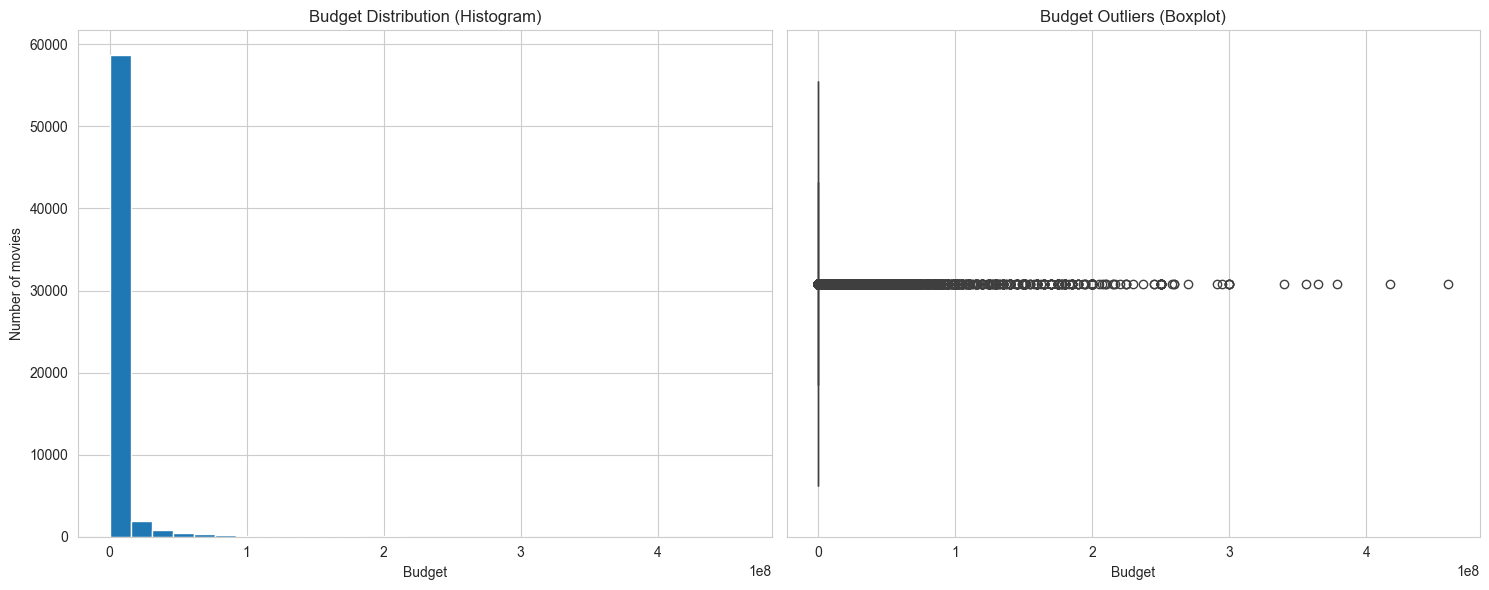

The amount of movies with budget above 1e8 (100000000$) is: 453


In [7]:
# Plot histogram and boxplot for budget side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histogram
data['budget'].hist(bins=30, ax=ax1)
ax1.set_title('Budget Distribution (Histogram)')
ax1.set_xlabel("Budget")
ax1.set_ylabel("Number of movies")

# Boxplot
sns.boxplot(x=data['budget'], ax=ax2)
ax2.set_title('Budget Outliers (Boxplot)')
ax2.set_xlabel("Budget")

plt.tight_layout()
plt.show()

print("The amount of movies with budget above 1e8 (100000000$) is: "+str((data['budget'] > 1e8).sum()))

In [8]:
print('The x axis represents the ranges of the budget while the y axis represents the number of movies')
print('It is evident that the distribution of the budget is highly right skewed and there is an existance of extreme cases')
print('The majority of the variables are near zero or have very low budget')
print('There are extreme outliers, with some movies having much larger budget than the majority')
print('Skewness and extreme values suggest that we might have to handle outliers when preprocessing')
print('The amount of movies with budget above 1e8 (100000000$) is:')
print((data['budget'] > 1e8).sum())

The x axis represents the ranges of the budget while the y axis represents the number of movies
It is evident that the distribution of the budget is highly right skewed and there is an existance of extreme cases
The majority of the variables are near zero or have very low budget
There are extreme outliers, with some movies having much larger budget than the majority
Skewness and extreme values suggest that we might have to handle outliers when preprocessing
The amount of movies with budget above 1e8 (100000000$) is:
453


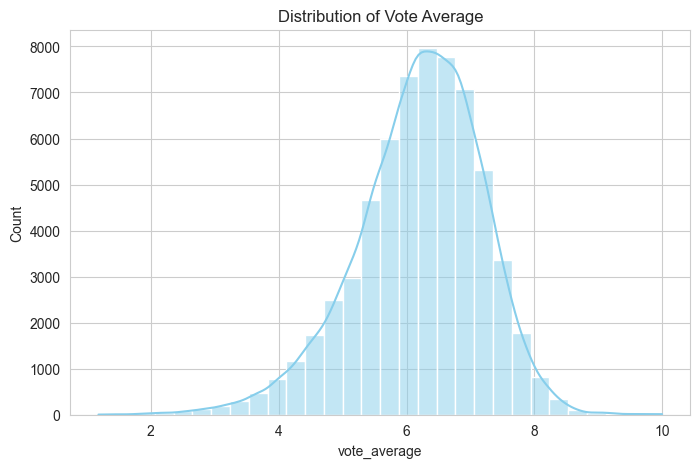

In [9]:
# Create figure and axes
fig, axes = plt.subplots(1, 1, figsize=(8, 5))

# Vote Average Distribution
sns.histplot(data['vote_average'], bins=30, kde=True, ax=axes, color='skyblue')
axes.set_title('Distribution of Vote Average')

plt.show()

In [10]:
print('The distribution of the vote average is bell shaped and close to normal')
print('Most movies are rated between 4 and 8 with the highest around 6')
print('This indicates that average is clustered near the middle and there are not many extreme cases affecting the distribution (very low or high ratings)')
print('The distribution is only slightly skewed')

The distribution of the vote average is bell shaped and close to normal
Most movies are rated between 4 and 8 with the highest around 6
This indicates that average is clustered near the middle and there are not many extreme cases affecting the distribution (very low or high ratings)
The distribution is only slightly skewed


In [11]:
# I will compare the mean with the median, if the mean has a higher value then it is right skewed, otherwise left skewed
print(data['vote_average'].mean(), data['vote_average'].median())
print('The movie ratings are slightly left skewed')

6.199307666666667 6.3
The movie ratings are slightly left skewed


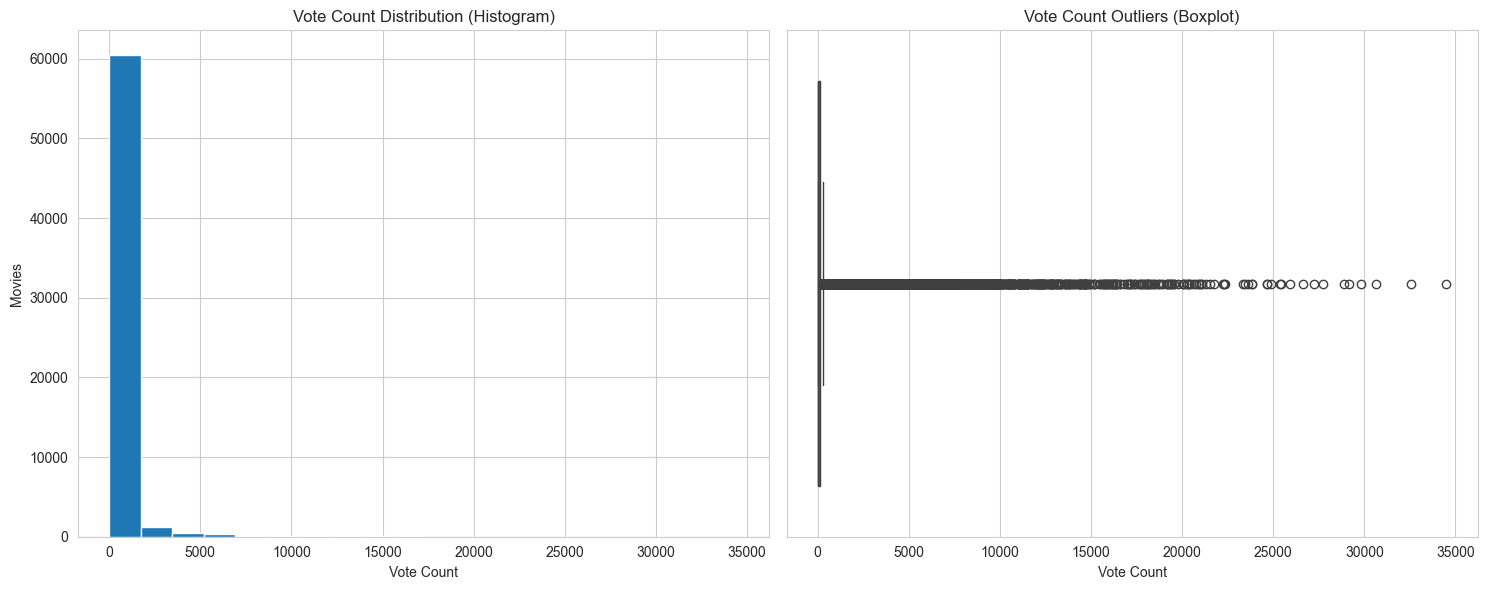

In [12]:
# Plot histogram and boxplot for vote count side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histogram
data['vote_count'].hist(bins=20, ax=ax1)
ax1.set_title('Vote Count Distribution (Histogram)')
ax1.set_xlabel("Vote Count")
ax1.set_ylabel("Movies")

# Boxplot
sns.boxplot(x=data['vote_count'], ax=ax2)
ax2.set_title('Vote Count Outliers (Boxplot)')
ax2.set_xlabel("Vote Count")

plt.tight_layout()
plt.show()

In [13]:
print('The shape of the distribution is highly right skewed, meaning that the vast majority have a few votes and a small number have a large amount of votes')
print('There are extreme outliers in this case')
print('Transformation or special handling will be required during preprocessing')

The shape of the distribution is highly right skewed, meaning that the vast majority have a few votes and a small number have a large amount of votes
There are extreme outliers in this case
Transformation or special handling will be required during preprocessing


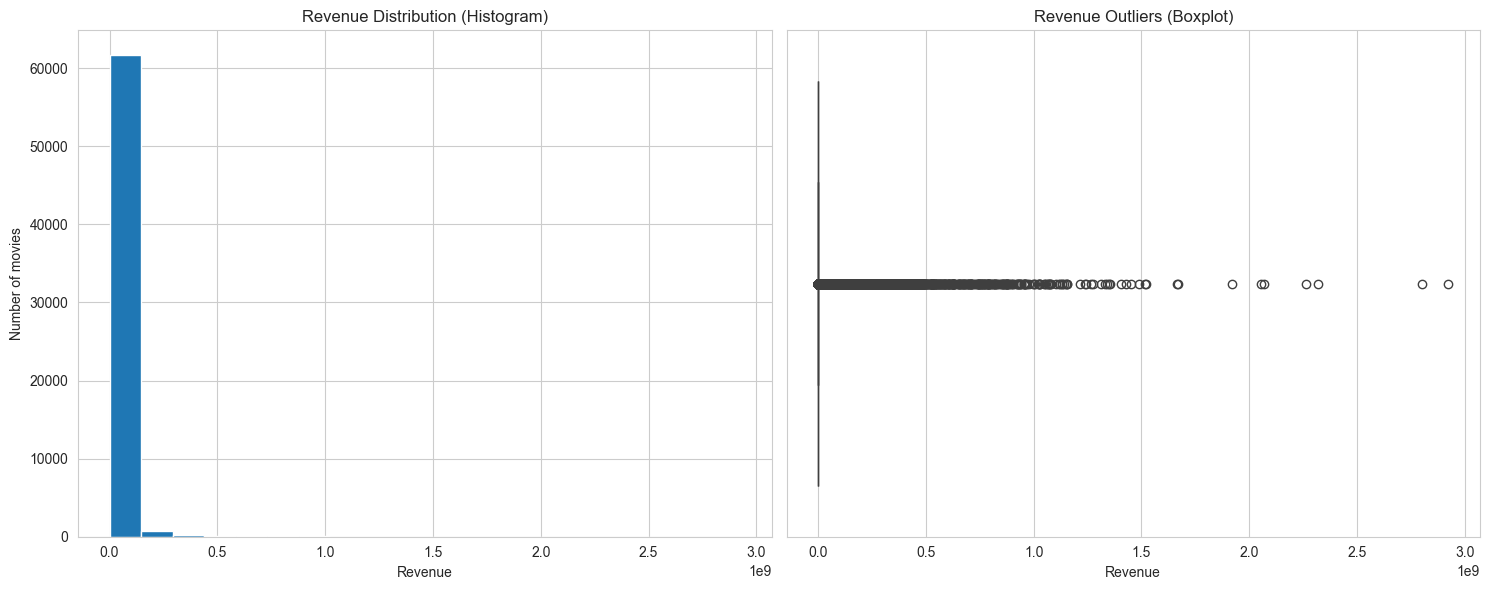

In [14]:
# Plot histogram and boxplot for revenue side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histogram
data['revenue'].hist(bins=20, ax=ax1)
ax1.set_title('Revenue Distribution (Histogram)')
ax1.set_xlabel("Revenue")
ax1.set_ylabel("Number of movies")

# Boxplot
sns.boxplot(x=data['revenue'], ax=ax2)
ax2.set_title('Revenue Outliers (Boxplot)')
ax2.set_xlabel("Revenue")

plt.tight_layout()
plt.show()

In [15]:
print('The shape of the distribution is highly right skewed, meaning that the vast majority have a small amount of revenue')
print('There are extreme cases corresponding to movies with hundreds of millions or billions in revenue')
print('1e9 stands for 1 billion')
print('Transformation or special handling will be required during preprocessing')

The shape of the distribution is highly right skewed, meaning that the vast majority have a small amount of revenue
There are extreme cases corresponding to movies with hundreds of millions or billions in revenue
1e9 stands for 1 billion
Transformation or special handling will be required during preprocessing


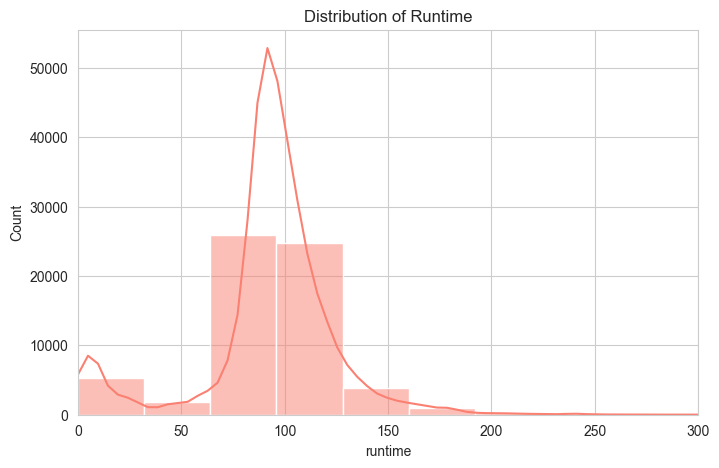

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

# Runtime Distribution
sns.histplot(data['runtime'], bins=30, kde=True, ax=ax, color='salmon')
ax.set_title('Distribution of Runtime')
ax.set_xlim(0, 300)

plt.show()

In [17]:
print('The shape of the distribution is right skewed, not as extreme as the previous though')
print('There is a small number of movies with unusually long runtimes')
print('Transformation or special handling will be required during preprocessing')

The shape of the distribution is right skewed, not as extreme as the previous though
There is a small number of movies with unusually long runtimes
Transformation or special handling will be required during preprocessing


Text(0, 0.5, 'Number of movies')

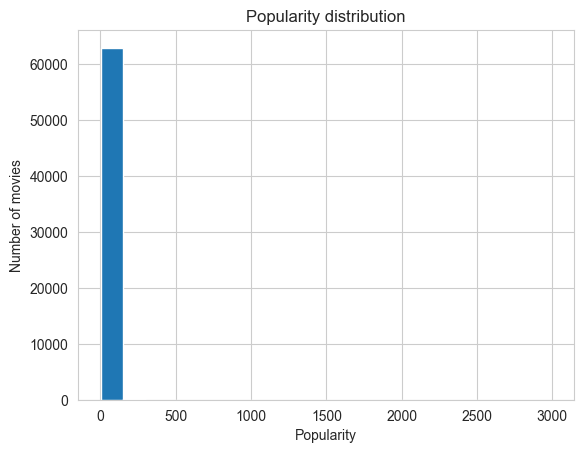

In [18]:
# Plot histogram for popularity
plt.figure()
data['popularity'].hist(bins=20)
plt.title('Popularity distribution')
plt.xlabel("Popularity")
plt.ylabel("Number of movies")

In [19]:
# Since the histogram did not help, we can get data without a visual
print('Information about column')
print(data['popularity'].describe())
print("Bin histogram")
print(pd.cut(data['popularity'], bins=[0,1,2,5,10,20,50,100,500,3000]).value_counts().sort_index())

Information about column
count    63000.000000
mean         8.725862
std         29.559384
min          0.600000
25%          2.849000
50%          4.957000
75%          9.278000
max       2994.357000
Name: popularity, dtype: float64
Bin histogram
popularity
(0, 1]          1080
(1, 2]          6891
(2, 5]         23769
(5, 10]        17023
(10, 20]       10061
(20, 50]        3406
(50, 100]        535
(100, 500]       211
(500, 3000]       24
Name: count, dtype: int64


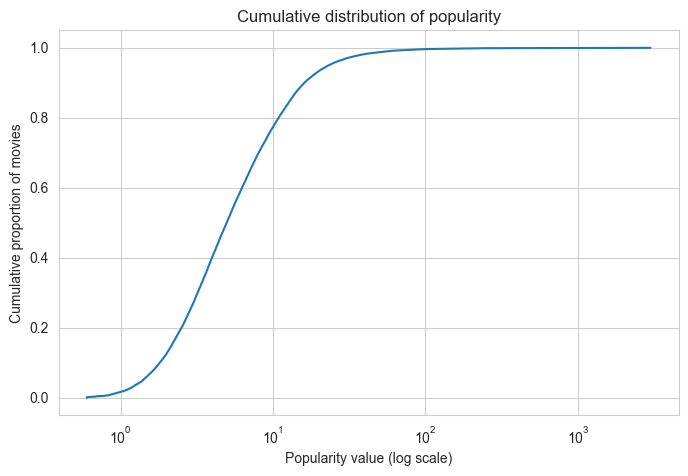

In [20]:
sorted_pop = np.sort(data['popularity'])
cumulative = np.arange(1, len(sorted_pop)+1) / len(sorted_pop)

plt.figure(figsize=(8, 5))
plt.plot(sorted_pop, cumulative)
plt.xscale('log')
plt.xlabel('Popularity value (log scale)')
plt.ylabel('Cumulative proportion of movies')
plt.title('Cumulative distribution of popularity')
plt.show()

In [21]:
print('Used the cumulative distribution function to visualize because histograms fail when distributions are extremely skewed due to outliers')
print('The CDF shows the entire distribution clearly')
print('We can now see that the popularity distribution is concentrated at low values (approx. 80% < 10)')
print('A small fraction of movies account for extremely high popularity and the distribution displays a high right skewness')

Used the cumulative distribution function to visualize because histograms fail when distributions are extremely skewed due to outliers
The CDF shows the entire distribution clearly
We can now see that the popularity distribution is concentrated at low values (approx. 80% < 10)
A small fraction of movies account for extremely high popularity and the distribution displays a high right skewness


### 1.4 Categorical Variable Analysis


In [22]:
# Now we should visualize the categorical columns using bar plots
# Due to high cardinality, many columns will be adjusted to have only the top 20 variables visualized
# So we can create a function that will create the bar plot for our needs
def bar_plot(column_name):
    top_langs = data[column_name].value_counts().head(20)

    plt.figure(figsize=(8,4))
    top_langs.plot(kind='bar')
    plt.title('Top 20 '+column_name)
    plt.xlabel(column_name)
    plt.ylabel('Number of movies')
    plt.show()

In [23]:
data['status'].value_counts()

status
Released    63000
Name: count, dtype: int64

In [24]:
print('All movies in the dataset belong to the released category, so they do not provide useful information for analysis and can be dropped in the preprocessing phase')

All movies in the dataset belong to the released category, so they do not provide useful information for analysis and can be dropped in the preprocessing phase


In [25]:
# Count movies by original language
data['original_language'].value_counts()

original_language
en    36983
fr     5189
it     3012
es     2877
ja     2504
      ...  
ln        1
si        1
mo        1
ff        1
so        1
Name: count, Length: 100, dtype: int64

C:\Users\emili\AppData\Local\Temp\ipykernel_19888\638076428.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_counts.index, y=lang_counts.values, palette='magma')


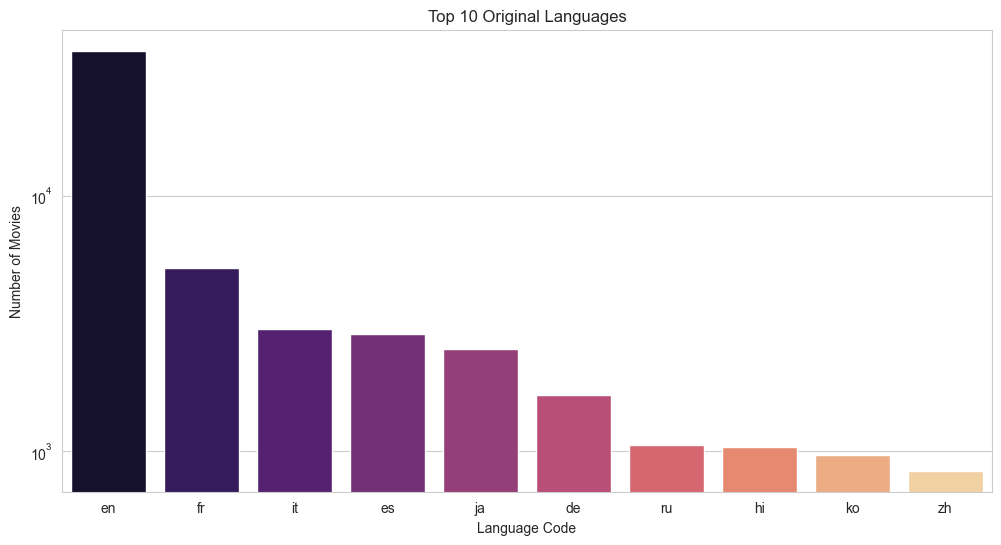

Percentage of movies in English: 58.70%


In [26]:
# Count movies by original language
lang_counts = data['original_language'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=lang_counts.index, y=lang_counts.values, palette='magma')
plt.title('Top 10 Original Languages')
plt.xlabel('Language Code')
plt.ylabel('Number of Movies')
plt.yscale('log') 
plt.show()

print(f"Percentage of movies in English: {(data['original_language'] == 'en').mean() * 100:.2f}%")

In [27]:
print('English demonstrates a strong dominance as the original language')
print('There is a long tail categorical distribution')
print('In preprocessing we can either classify lower languages as "other" or keep only top N languages')

English demonstrates a strong dominance as the original language
There is a long tail categorical distribution
In preprocessing we can either classify lower languages as "other" or keep only top N languages


In [28]:
# Count movies by genres
data['genres'].value_counts()

genres
Drama                                  5862
Comedy                                 5505
Documentary                            2932
Drama, Romance                         1763
Horror                                 1697
                                       ... 
Mystery, TV Movie, Drama, Thriller        1
Action, Fantasy, Adventure, History       1
Comedy, Drama, Music, War                 1
Documentary, History, Drama, Comedy       1
Comedy, Family, Adventure, Action         1
Name: count, Length: 5729, dtype: int64

C:\Users\emili\AppData\Local\Temp\ipykernel_19888\3094621295.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')


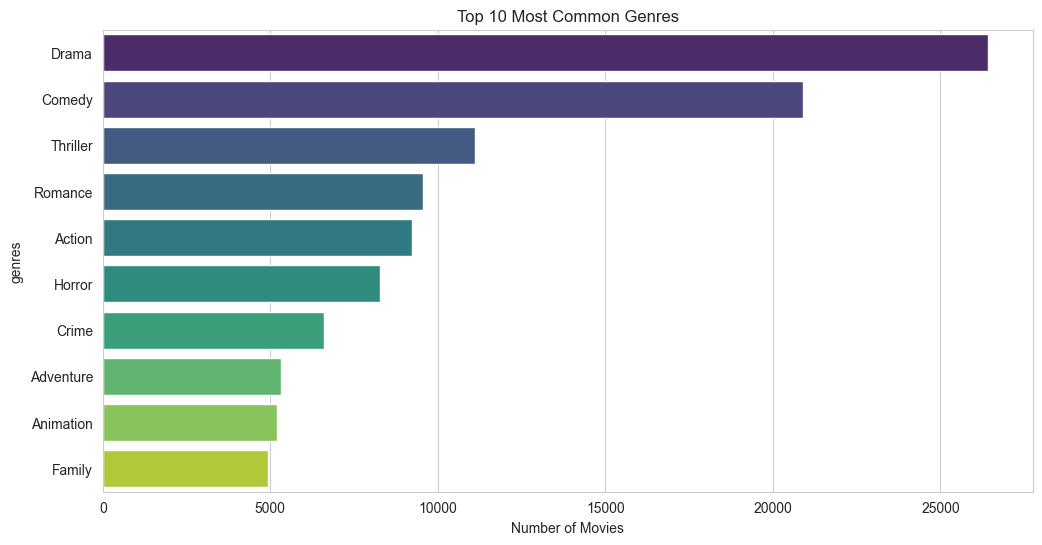

In [29]:
# Split the genres string by comma and explode them into separate rows
genres_exploded = data['genres'].str.split(', ').explode()

# Count the occurrences of each genre
genre_counts = genres_exploded.value_counts().head(10)

# Plot top 10 genres
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Top 10 Most Common Genres')
plt.xlabel('Number of Movies')
plt.show()

In [30]:
print('Drama and comedy represent a large amount of the genres in the dataset')
print('There is a long tail categorical distribution')
print('The plot also shows the most frequent genre combinations and not just individual genres')
print('In preprocessing we will either classify genders that do not appear as much as "other" or keep only top N genres')
print('Also in preprocessing we will have to split genres into lists and split them into individual genres')
print('In summary the genres column has high cardinality, many rare category combinations and dominant genres')

Drama and comedy represent a large amount of the genres in the dataset
There is a long tail categorical distribution
The plot also shows the most frequent genre combinations and not just individual genres
In preprocessing we will either classify genders that do not appear as much as "other" or keep only top N genres
Also in preprocessing we will have to split genres into lists and split them into individual genres
In summary the genres column has high cardinality, many rare category combinations and dominant genres


In [31]:
# Count movies by production companies
data['production_companies'].value_counts()

production_companies
Metro-Goldwyn-Mayer                                                                                                                            463
Walt Disney Productions                                                                                                                        447
Paramount                                                                                                                                      378
20th Century Fox                                                                                                                               377
Warner Bros. Pictures                                                                                                                          349
                                                                                                                                              ... 
Imagina International Sales, Pontas Films, Golem, Ministerio de Cultura España, TV3, Generalitat 

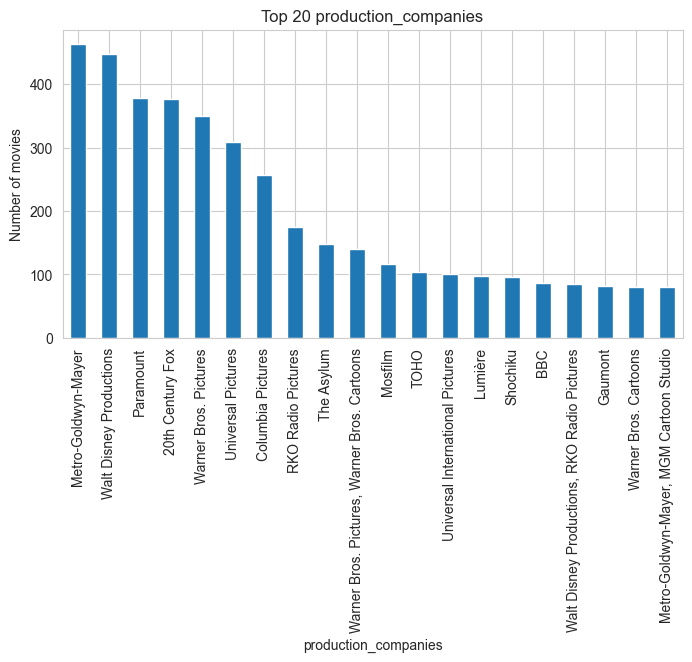

In [32]:
bar_plot('production_companies')

In [33]:
print('A small number of large studios dominate the dataset, there is a long tail and a high imbalance due to a small number of companies producing a large share of the movies.')
print('Additionally, there is high cardinality in this column and multiple production companies per movie')
print('For preprocessing might need to group rare companies to "other" and split combined companies per movie')

A small number of large studios dominate the dataset, there is a long tail and a high imbalance due to a small number of companies producing a large share of the movies.
Additionally, there is high cardinality in this column and multiple production companies per movie
For preprocessing might need to group rare companies to "other" and split combined companies per movie


In [34]:
# Count movies by production countries
data['production_countries'].value_counts()

production_countries
United States of America                              23403
France                                                 3566
United Kingdom                                         3082
Japan                                                  2381
Italy                                                  2247
                                                      ...  
Denmark, Finland, Sweden, United States of America        1
France, Ireland, Lithuania, Russia                        1
Belgium, Canada, United States of America                 1
Finland, Hungary                                          1
Austria, Yugoslavia                                       1
Name: count, Length: 3243, dtype: int64

C:\Users\emili\AppData\Local\Temp\ipykernel_19888\1061688088.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette='Spectral')


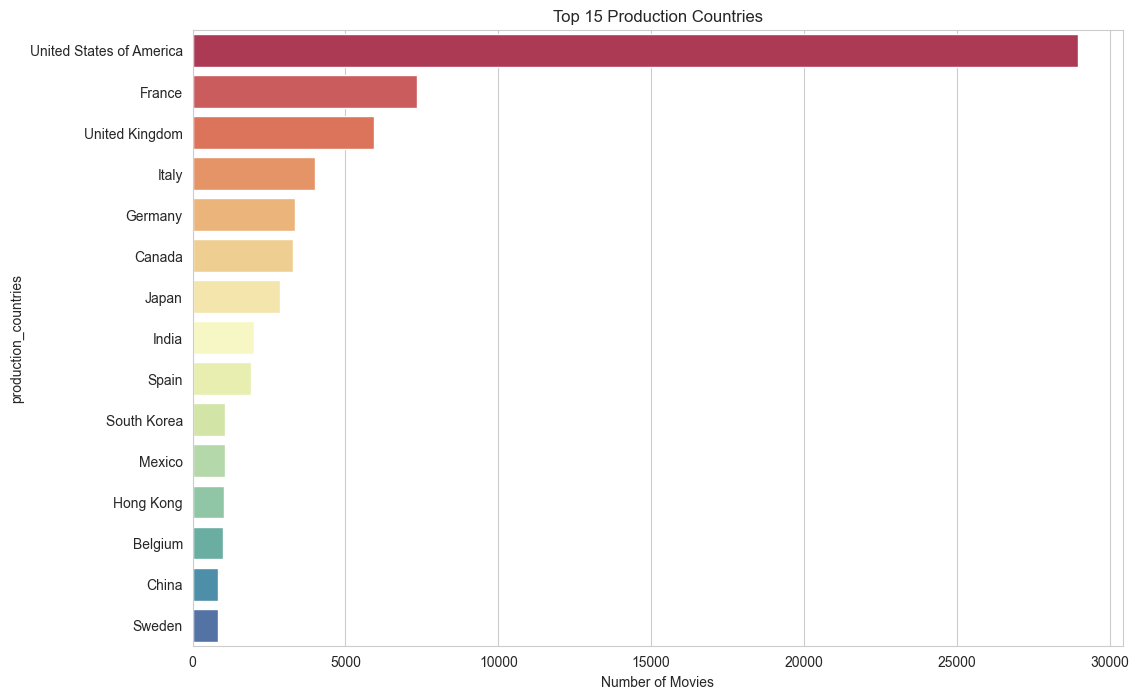

In [35]:
# Handle missing values in production_countries before splitting
countries_exploded = data['production_countries'].fillna('').str.split(', ').explode()

# Remove empty strings 
countries_exploded = countries_exploded[countries_exploded != '']

# Plot top 15 Countries
country_counts = countries_exploded.value_counts().head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=country_counts.values, y=country_counts.index, palette='Spectral')
plt.title('Top 15 Production Countries')
plt.xlabel('Number of Movies')
plt.show()

In [36]:
print('The dataset is dominated by few countries, especially US')
print('There is a long tail of rare country combinations, meaning that cardinality is inflated due to multi-valued categorical encoding')
print('For preprocessing might need to group rare companies to "other" and split combined production countries')

The dataset is dominated by few countries, especially US
There is a long tail of rare country combinations, meaning that cardinality is inflated due to multi-valued categorical encoding
For preprocessing might need to group rare companies to "other" and split combined production countries


In [37]:
# Count movies by spoken languages
data['spoken_languages'].value_counts()

spoken_languages
English                                                     28702
French                                                       3568
Italian                                                      2419
Spanish                                                      2339
Japanese                                                     2249
                                                            ...  
English, Spanish, Catalan, Tagalog                              1
English, French, Hindi, German                                  1
French, Inuktitut                                               1
German, English, French, Italian, Polish, Swedish, Czech        1
Serbo-Croatian, German                                          1
Name: count, Length: 2952, dtype: int64

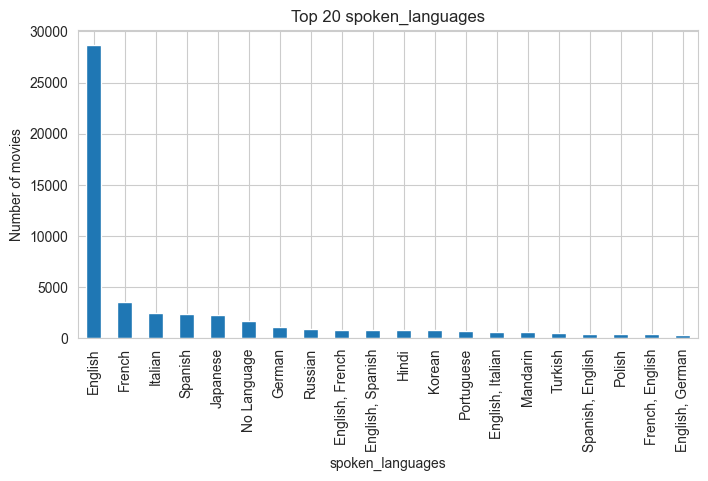

In [38]:
bar_plot('spoken_languages')

In [39]:
print('English is the dominant category and there is a long tail of rare language combinations')
print('Exhibits very high cardinality which mostly artificially inflated thanks to combinations.')
print('For preprocessing we will have to split languages and group non frequent into "other"')

English is the dominant category and there is a long tail of rare language combinations
Exhibits very high cardinality which mostly artificially inflated thanks to combinations.
For preprocessing we will have to split languages and group non frequent into "other"


### 1.5 Data Quality Checks


In [40]:
# Count movies by title
data['title'].value_counts()

title
Cinderella                                  19
Return                                      15
Red                                         13
Alice in Wonderland                         11
Alone                                       10
                                            ..
Unless                                       1
Life of Josutty                              1
Zona J                                       1
Son of Fury: The Story of Benjamin Blake     1
The Fearless Freaks                          1
Name: count, Length: 57867, dtype: int64

In [41]:
print('This categorical feature is not very practical as most titles are unique')
print('Due to very high cardinality, will not be needed in preprocessing')

This categorical feature is not very practical as most titles are unique
Due to very high cardinality, will not be needed in preprocessing


### 1.6 Additional Exploratory Visualizations


In [42]:
print('The cardinality of each column is demonstrated in the following table')
data.nunique().sort_values(ascending=False)

The cardinality of each column is demonstrated in the following table


id                      63000
title                   57867
production_companies    40797
release_date            20443
popularity              18834
revenue                 11525
genres                   5729
vote_average             4884
vote_count               3584
production_countries     3243
spoken_languages         2952
budget                   2127
runtime                   323
original_language         100
status                      1
dtype: int64

In [43]:
print('In preprocessing there will be a challenge for high cardinality variables')

In preprocessing there will be a challenge for high cardinality variables


In [44]:
# Second: Checking for duplicate rows
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# If any duplicate row is found, we are going to drop it
if duplicates > 0:
    data = data.drop_duplicates()
    print("Duplicates removed.")

Number of duplicate rows: 0


In [45]:
# Convert release_date to datetime, handling mixed formats
data['release_date'] = pd.to_datetime(data['release_date'], format='mixed', dayfirst=True, errors='coerce')

# Extract Year and Month for analysis
data['release_year'] = data['release_date'].dt.year
data['release_month'] = data['release_date'].dt.month_name()

print("Dates converted. Null dates:", data['release_date'].isna().sum())
data.head(3)

Dates converted. Null dates: 27


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,original_language,popularity,genres,production_companies,production_countries,spoken_languages,release_year,release_month
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,160000000,en,83.952,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili",2010.0,July
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,165000000,en,140.241,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,2014.0,November
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,185000000,en,130.643,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin",2008.0,July


In [46]:
# Summary statistics for numerical columns
numerical_stats = data.describe()

# Check specifically for "zero" values which might indicate missing information
zero_budget = (data['budget'] == 0).sum()
zero_revenue = (data['revenue'] == 0).sum()

print(f"Movies with 0 Budget: {zero_budget}")
print(f"Movies with 0 Revenue: {zero_revenue}")
display(numerical_stats)

Movies with 0 Budget: 49470
Movies with 0 Revenue: 50111


,id,vote_average,vote_count,release_date,revenue,runtime,budget,popularity,release_year
count,6.300000e+04,63000.000000,63000.000000,62973,6.300000e+04,63000.000000,6.300000e+04,63000.000000,62973.000000
mean,2.227146e+05,6.199308,326.487032,1998-03-25 13:36:18.247820544,1.116228e+07,92.712603,4.163998e+06,8.725862,1997.711400
min,2.000000e+00,1.179000,14.000000,1874-12-09 00:00:00,0.000000e+00,0.000000,0.000000e+00,0.600000,1874.000000
25%,3.560950e+04,5.600000,22.000000,1987-02-01 00:00:00,0.000000e+00,85.000000,0.000000e+00,2.849000,1987.000000
50%,8.975700e+04,6.300000,41.000000,2007-11-16 00:00:00,0.000000e+00,95.000000,0.000000e+00,4.957000,2007.000000
75%,3.765025e+05,6.900000,126.000000,2016-03-10 00:00:00,0.000000e+00,107.000000,0.000000e+00,9.278000,2016.000000
max,1.186774e+06,10.000000,34495.000000,2023-10-03 00:00:00,2.923706e+09,960.000000,4.600000e+08,2994.357000,2023.000000
std,2.521255e+05,0.992356,1315.334908,NaN,6.718081e+07,34.771182,1.768219e+07,29.559384,24.890506


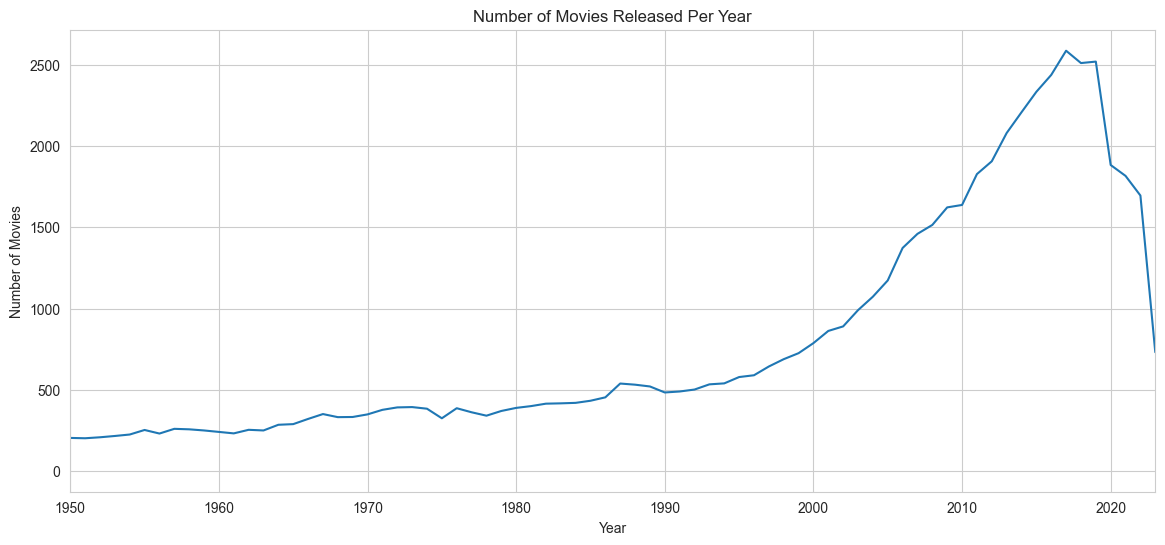

In [47]:
plt.figure(figsize=(14, 6))
# Count movies per year, sort by year
movies_per_year = data['release_year'].value_counts().sort_index()

# Plot line chart
sns.lineplot(x=movies_per_year.index, y=movies_per_year.values)
plt.title('Number of Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.xlim(1950, 2023) # Focus on the movies released after 1950
plt.show()

## Conclusions from Initial Data Analysis

- The dataset contains approximately 63,000 movies with 15 features, including numerical, categorical, and multi-valued categorical variables.
- Several numerical variables (`budget`, `revenue`, `vote_count`, `popularity`) exhibit strong right skewness and contain extreme values.
- A large proportion of movies have zero or missing values for `budget` and `revenue`, suggesting unreported financial data rather than true zeros.
- Multi-valued categorical features such as `genres`, `production_companies`, `production_countries`, and `spoken_languages` require splitting into individual categories for meaningful analysis.
- Certain categorical variables have very high cardinality (e.g., `title`, `production_companies`), which will require grouping rare categories or alternative encoding strategies.
- The `status` feature contains only a single category and does not provide useful information for further analysis.
- Missing values are concentrated in a small subset of columns and will require column-specific handling during preprocessing.

These observations will guide the preprocessing stage, including missing value treatment, feature transformation, and encoding decisions.


---

## Part 2: Data Preprocessing Pipeline

This section implements the complete preprocessing pipeline to clean and prepare the data for analysis.


# Analysis Pipeline for Movies Dataset

This notebook preprocesses data for exploratory analysis and relationship exploration.

## Pipeline Steps:
1. Data Cleaning and Filtering
2. Handle Zero Values (Convert to NaN)
3. Extract Date Features
4. Feature Engineering - Business Metrics
5. Handle Missing Values for Analysis
6. Expand Multi-valued Categorical Features
7. Create Additional Temporal Features
8. Create Additional Derived Features


In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

## STEP 1: Data Cleaning and Filtering

Remove noise from the dataset:
- Drop duplicates
- Filter runtime outliers (0 < runtime <= 300)
- Filter vote_count for reliability (>= 10)
- Drop rows with invalid release dates


In [49]:
def filter_noise(df):
    # Make a copy of the dataset before preprocessing it
    df = df.copy()
    
    # Drop duplicates
    df = df.drop_duplicates()
    
    # Filter runtime outliers (0 < runtime <= 300)
    df = df[(df['runtime'] > 0) & (df['runtime'] <= 300)]
    
    # Filter vote_count for reliability 
    df = df[df['vote_count'] >= 10]
    
    # Drop rows with no release date. This is imprtant for year analysis
    temp_dates = pd.to_datetime(df['release_date'], dayfirst=True, format='mixed', errors='coerce')
    df = df[temp_dates.notna()]
    
    return df

# Load and filter data
raw_data = pd.read_csv('movies.csv')
print(f"Initial shape: {raw_data.shape}")

df_filtered = filter_noise(raw_data)
print(f"After filtering: {df_filtered.shape}")


Initial shape: (63000, 15)
After filtering: (62216, 15)


## STEP 2: Handle Zero Values (Convert to NaN)

Convert zero values to NaN for budget, revenue, and runtime.
These zeros typically represent missing data rather than true zeros.


In [50]:
def replace_zeros(df):
    df = df.copy()
    cols = ['budget', 'revenue', 'runtime']
    for col in cols:
        if col in df.columns:
            df[col] = df[col].replace(0, np.nan)
    return df

df_step2 = replace_zeros(df_filtered)
print(f"Shape: {df_step2.shape}")
print(f"Missing values after zero replacement:")
print(df_step2[['budget', 'revenue', 'runtime']].isnull().sum())


Shape: (62216, 15)
Missing values after zero replacement:
budget     48721
revenue    49348
runtime        0
dtype: int64


## STEP 3: Extract Date Features

Extract temporal features from release_date:
- Convert to datetime
- Extract release_year
- Extract release_month (month name)


In [51]:
def extract_date_features(df):
    df = df.copy()
    
    # Convert release_date to datetime
    df['release_date'] = pd.to_datetime(df['release_date'], dayfirst=True, format='mixed', errors='coerce')
    
    # Extract release year
    df['release_year'] = df['release_date'].dt.year
    
    # Extract release month 
    df['release_month'] = df['release_date'].dt.month_name()
    
    return df

df_step3 = extract_date_features(df_step2)
print(f"Shape: {df_step3.shape}")
print(f"\nDate features created:")
print(df_step3[['release_date', 'release_year', 'release_month']].head())


Shape: (62216, 17)

Date features created:
  release_date  release_year release_month
0   2010-07-15          2010          July
1   2014-11-05          2014      November
2   2008-07-16          2008          July
3   2009-12-15          2009      December
4   2012-04-25          2012         April


## STEP 4: Feature Engineering - Business Metrics

Create business-related features:
- profit = revenue - budget
- roi = (revenue - budget) / budget
- primary_genre (first genre from genres list)


In [52]:
def create_business_features(df):
    df = df.copy()
    
    # Profit and ROI
    if 'revenue' in df.columns and 'budget' in df.columns:
        df['profit'] = df['revenue'] - df['budget']
        # ROI calculation. We also handle devision by zero.
        df['roi'] = np.where(df['budget'] != 0, 
                            (df['revenue'] - df['budget']) / df['budget'], 
                            np.nan)
    
    # Extract primary genre (first genre in the list)
    if 'genres' in df.columns:
        df['primary_genre'] = df['genres'].astype(str).str.split(',').str[0].str.strip()
        # Handle 'nan' strings
        df['primary_genre'] = df['primary_genre'].replace('nan', np.nan)
    
    return df

df_step4 = create_business_features(df_step3)
print(f"Shape: {df_step4.shape}")
print(f"\nBusiness features created:")
print(df_step4[['profit', 'roi', 'primary_genre']].head())


Shape: (62216, 20)

Business features created:
         profit        roi    primary_genre
0  6.655328e+08   4.159580           Action
1  5.367292e+08   3.252904        Adventure
2  8.195584e+08   4.430046            Drama
3  2.686706e+09  11.336312           Action
4  1.298816e+09   5.903707  Science Fiction


## STEP 5: Handle Missing Values for Analysis

Handle missing values for analysis:
- production_companies: fill with 'Unknown' (preserves missingness info)
- production_countries, genres, spoken_languages: handle NaN values


In [53]:
def handle_missing_values(df):
    df = df.copy()
    
    # Fill production_companies with 'Unknown' 
    if 'production_companies' in df.columns:
        df['production_companies'] = df['production_companies'].fillna('Unknown')
    
    # Handle other multi-valued categorical columns
    # Convert float NaN to string 'Unknown' for consistency
    for col in ['production_countries', 'genres', 'spoken_languages']:
        if col in df.columns:
            # Fill NaN with 'Unknown'
            df[col] = df[col].fillna('Unknown')
    
    return df

df_step5 = handle_missing_values(df_step4)
print(f"Shape: {df_step5.shape}")
print(f"\nMissing values after handling:")
print(df_step5[['production_companies', 'production_countries', 'genres', 'spoken_languages']].isnull().sum())


Shape: (62216, 20)

Missing values after handling:
production_companies    0
production_countries    0
genres                  0
spoken_languages        0
dtype: int64


## STEP 6: Expand Multi-valued Categorical Features

Expand multi-valued categorical features for analysis:
- Extract all genres (not just primary)
- Extract primary production country
- Extract primary spoken language
- Create counts for multi-valued features


In [54]:
def expand_categorical_features(df):
    df = df.copy()
    
    # Extract all genres and create genre count
    if 'genres' in df.columns:
        df['genre_count'] = df['genres'].astype(str).str.split(',').str.len()
        df['genre_count'] = df['genre_count'].replace(0, np.nan)  # Handle empty strings
    
    # Extract primary production country
    if 'production_countries' in df.columns:
        df['primary_country'] = df['production_countries'].astype(str).str.split(',').str[0].str.strip()
        df['primary_country'] = df['primary_country'].replace('nan', np.nan)
        df['country_count'] = df['production_countries'].astype(str).str.split(',').str.len()
        df['country_count'] = df['country_count'].replace(0, np.nan)
    
    # Extract primary spoken language
    if 'spoken_languages' in df.columns:
        df['primary_language'] = df['spoken_languages'].astype(str).str.split(',').str[0].str.strip()
        df['primary_language'] = df['primary_language'].replace('nan', np.nan)
        df['language_count'] = df['spoken_languages'].astype(str).str.split(',').str.len()
        df['language_count'] = df['language_count'].replace(0, np.nan)
    
    # Extract primary production company
    if 'production_companies' in df.columns:
        df['primary_company'] = df['production_companies'].astype(str).str.split(',').str[0].str.strip()
        df['primary_company'] = df['primary_company'].replace('nan', 'Unknown')
        df['company_count'] = df['production_companies'].astype(str).str.split(',').str.len()
        df['company_count'] = df['company_count'].replace(0, np.nan)
    
    return df

df_step6 = expand_categorical_features(df_step5)
print(f"Shape: {df_step6.shape}")
print(f"\nNew categorical features:")
print(df_step6[['genre_count', 'primary_country', 'primary_language', 'primary_company']].head())


Shape: (62216, 27)

New categorical features:
   genre_count           primary_country primary_language     primary_company
0            3            United Kingdom          English  Legendary Pictures
1            3            United Kingdom          English  Legendary Pictures
2            4            United Kingdom          English           DC Comics
3            4  United States of America          English  Dune Entertainment
4            3  United States of America          English      Marvel Studios


## STEP 7: Create Additional Temporal Features

Create additional temporal features:
- release_quarter (Q1-Q4)
- release_decade
- is_summer_blockbuster (May-August)


In [55]:
def create_temporal_features(df):
    df = df.copy()
    
    if 'release_date' in df.columns:
        # Release quarter
        df['release_quarter'] = df['release_date'].dt.quarter
        df['release_quarter'] = df['release_quarter'].map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'})
        
        # Release decade
        df['release_decade'] = (df['release_year'] // 10) * 10
        
        # Summer blockbuster flag (May-August)
        df['is_summer_blockbuster'] = df['release_date'].dt.month.isin([5, 6, 7, 8])
        
    
    return df

df_step7 = create_temporal_features(df_step6)
print(f"Shape: {df_step7.shape}")
print(f"\nNew temporal features:")
print(df_step7[['release_quarter', 'release_decade', 'is_summer_blockbuster']].head())


Shape: (62216, 30)

New temporal features:
  release_quarter  release_decade  is_summer_blockbuster
0              Q3            2010                   True
1              Q4            2010                  False
2              Q3            2000                   True
3              Q4            2000                  False
4              Q2            2010                  False


## STEP 8: Create Additional Derived Features

Create additional derived features for analysis:
- budget_revenue_ratio
- vote_reliability (weighted vote average)
- runtime_bins (Short/Medium/Long)
- financial_success flag


In [56]:
def create_derived_features(df):
    df = df.copy()
    
    # Budget to revenue ratio
    if 'budget' in df.columns and 'revenue' in df.columns:
        df['budget_revenue_ratio'] = np.where(df['budget'] > 0,
                                             df['revenue'] / df['budget'],
                                             np.nan)
    
    # Vote reliability (weighted by vote count)
    if 'vote_average' in df.columns and 'vote_count' in df.columns:
        df['vote_reliability'] = df['vote_average'] * np.log1p(df['vote_count'])
    
    # Runtime bins
    if 'runtime' in df.columns:
        df['runtime_bins'] = pd.cut(df['runtime'], 
                                   bins=[0, 90, 120, 300],
                                   labels=['Short', 'Medium', 'Long'],
                                   include_lowest=True)
    
    # Financial success flag (revenue > 2 * budget)
    if 'revenue' in df.columns and 'budget' in df.columns:
        df['financial_success'] = df['revenue'] > (2 * df['budget'])
    
    return df

df_step8 = create_derived_features(df_step7)
print(f"Shape: {df_step8.shape}")
print(f"\nNew derived features:")
print(df_step8[['budget_revenue_ratio', 'vote_reliability', 'runtime_bins', 'financial_success']].head())


Shape: (62216, 34)

New derived features:
   budget_revenue_ratio  vote_reliability runtime_bins  financial_success
0              5.159580         87.392079         Long               True
1              4.252904         87.462800         Long               True
2              5.430046         87.923927         Long               True
3             12.336312         78.023108         Long               True
4              6.903707         79.264916         Long               True


## Final Step: Save Preprocessed Dataset

Save the cleaned and preprocessed dataset for analysis.


In [57]:
# Final dataset for analysis
df_analysis = df_step8.copy()

print("Preprocessing Complete!")
print(f"Final shape: {df_analysis.shape}")
print(f"\nColumns: {df_analysis.columns.tolist()}")

# Save the new cleaned and preprocessed dataset
df_analysis.to_csv('movies_cleaned_analysis.csv', index=False)
print("\nThe cleaned dataset is saved as 'movies_cleaned_analysis.csv'")

# Display first few rows
df_analysis.head()


Preprocessing Complete!
Final shape: (62216, 34)

Columns: ['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'budget', 'original_language', 'popularity', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'release_year', 'release_month', 'profit', 'roi', 'primary_genre', 'genre_count', 'primary_country', 'country_count', 'primary_language', 'language_count', 'primary_company', 'company_count', 'release_quarter', 'release_decade', 'is_summer_blockbuster', 'budget_revenue_ratio', 'vote_reliability', 'runtime_bins', 'financial_success']

The cleaned dataset is saved as 'movies_cleaned_analysis.csv'


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,original_language,...,language_count,primary_company,company_count,release_quarter,release_decade,is_summer_blockbuster,budget_revenue_ratio,vote_reliability,runtime_bins,financial_success
0,27205,Inception,8.364,34495,Released,2010-07-15,8.255328e+08,148,160000000.0,en,...,4,Legendary Pictures,3,Q3,2010,True,5.159580,87.392079,Long,True
1,157336,Interstellar,8.417,32571,Released,2014-11-05,7.017292e+08,169,165000000.0,en,...,1,Legendary Pictures,3,Q4,2010,False,4.252904,87.462800,Long,True
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1.004558e+09,152,185000000.0,en,...,2,DC Comics,5,Q3,2000,True,5.430046,87.923927,Long,True
3,19995,Avatar,7.573,29815,Released,2009-12-15,2.923706e+09,162,237000000.0,en,...,2,Dune Entertainment,4,Q4,2000,False,12.336312,78.023108,Long,True
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1.518816e+09,143,220000000.0,en,...,3,Marvel Studios,1,Q2,2010,False,6.903707,79.264916,Long,True


---

## Part 3: Regression Preparation

This section prepares the preprocessed data for regression analysis by encoding categorical features and scaling numerical features.


# Regression Pipeline for Movies Dataset

This notebook preprocesses data for **linear or logistic regression** to analyze relationships.

**Note:** This pipeline uses the output from `analysis_pipeline.ipynb` (`movies_cleaned_analysis.csv`).

## Simplified Pipeline Steps:
1. Load Analysis-Ready Data
2. Select Features (Simple Numerical + Categorical)
3. Handle Missing Values
4. Encode Categorical Features (One-Hot Encoding)
5. Scale Numerical Features (Optional but Recommended)
6. Save Preprocessed Dataset


In [58]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


## STEP 1: Load Analysis-Ready Data

Load the preprocessed dataset from the analysis pipeline.


In [59]:
# Load analysis-ready data
df = pd.read_csv('movies_cleaned_analysis.csv')
print(f"Initial shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()


Initial shape: (62216, 34)

First few rows:


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,original_language,...,language_count,primary_company,company_count,release_quarter,release_decade,is_summer_blockbuster,budget_revenue_ratio,vote_reliability,runtime_bins,financial_success
0,27205,Inception,8.364,34495,Released,2010-07-15,8.255328e+08,148,160000000.0,en,...,4,Legendary Pictures,3,Q3,2010,True,5.159580,87.392079,Long,True
1,157336,Interstellar,8.417,32571,Released,2014-11-05,7.017292e+08,169,165000000.0,en,...,1,Legendary Pictures,3,Q4,2010,False,4.252904,87.462800,Long,True
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1.004558e+09,152,185000000.0,en,...,2,DC Comics,5,Q3,2000,True,5.430046,87.923927,Long,True
3,19995,Avatar,7.573,29815,Released,2009-12-15,2.923706e+09,162,237000000.0,en,...,2,Dune Entertainment,4,Q4,2000,False,12.336312,78.023108,Long,True
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1.518816e+09,143,220000000.0,en,...,3,Marvel Studios,1,Q2,2010,False,6.903707,79.264916,Long,True


## STEP 2: Select Features for Regression

Select features that match exactly what will be used in relationships_regression_analysis.ipynb:
- Numerical: budget, runtime, vote_count, vote_reliability (or vote_average), popularity, is_summer
- Categorical: primary_genre (one-hot encoded)


In [60]:
# Drop unnecessary columns
columns_to_drop = ['id', 'title', 'status']
for col in columns_to_drop:
    if col in df.columns:
        df = df.drop(columns=[col])

# Select numerical features 
numerical_features = [
    'budget', 'runtime', 'vote_count', 'vote_average', 
    'popularity', 'release_year'
]

# Select categorical features 
categorical_features = [
    'original_language', 'primary_genre', 'primary_country', 'release_month'
]

# Filter to only include columns that exist
numerical_features = [f for f in numerical_features if f in df.columns]
categorical_features = [f for f in categorical_features if f in df.columns]

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")
print(f"\nData shape: {df.shape}")


Numerical features (6): ['budget', 'runtime', 'vote_count', 'vote_average', 'popularity', 'release_year']

Categorical features (4): ['original_language', 'primary_genre', 'primary_country', 'release_month']

Data shape: (62216, 31)


## STEP 3: Handle Missing Values

Impute missing values:
- Numerical: median imputation
- Categorical: fill with 'Unknown'


In [61]:
# Check missing values
print("Missing values in selected features:")
print(f"\nNumerical features:")
for col in numerical_features:
    missing = df[col].isnull().sum()
    if missing > 0:
        print(f"  {col}: {missing} ({missing/len(df)*100:.1f}%)")

print(f"\nCategorical features:")
for col in categorical_features:
    missing = df[col].isnull().sum()
    if missing > 0:
        print(f"  {col}: {missing} ({missing/len(df)*100:.1f}%)")


Missing values in selected features:

Numerical features:
  budget: 48721 (78.3%)

Categorical features:
  primary_genre: 403 (0.6%)


## STEP 4: Encode and Scale Features

Apply preprocessing (matching relationships_regression_analysis.ipynb approach):
- Numerical: median imputation + standardization
- Categorical: fill 'Unknown' + one-hot encoding (drop_first=True to match pd.get_dummies behavior)


### 4.1 Financial Data Filtering

Filter to movies with complete financial information for accurate analysis.


### 4.2 Correlation Overview

Exploratory correlation analysis of key numerical variables.


In [62]:
# Create preprocessing pipelines
# Note: Using drop_first=True in OneHotEncoder to match pd.get_dummies behavior
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_features),
        ('cat', cat_pipeline, categorical_features)
    ],
    verbose_feature_names_out=False
)

# Fit and transform
print("Fitting preprocessor...")
processed_array = preprocessor.fit_transform(df)

# Get column names
numeric_names = numerical_features
categorical_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
# OneHotEncoder already produces names like 'primary_genre_GenreName', which matches pd.get_dummies format
all_columns = list(numeric_names) + list(categorical_names)

# Create final dataframe with preprocessed features
df_regression = pd.DataFrame(processed_array, columns=all_columns)

# Also keep target variables and other necessary columns for relationships_regression_analysis
target_cols = ['revenue', 'budget']  # Needed for financial_success calculation
if 'financial_success' in df.columns:
    target_cols.append('financial_success')

# Add target columns to the preprocessed dataframe
for col in target_cols:
    if col in df.columns:
        df_regression[col] = df[col].values

print(f"Final shape: {df_regression.shape}")
print(f"Features: {len(all_columns)} preprocessed features")
print(f"Targets included: {[col for col in target_cols if col in df_regression.columns]}")
print("Preprocessing complete!")


Fitting preprocessor...
Final shape: (62216, 294)
Features: 292 preprocessed features
Targets included: ['revenue', 'budget', 'financial_success']
Preprocessing complete!


## STEP 5: Save Preprocessed Dataset

Save the regression-ready dataset.


In [63]:
# Save preprocessed data
output_file = 'movies_regression_ready.csv'
df_regression.to_csv(output_file, index=False)
print(f"Preprocessed dataset saved as '{output_file}'")
print(f"\nShape: {df_regression.shape}")
print(all_columns)
print(f"\nTarget variables included: {[col for col in target_cols if col in df_regression.columns]}")
print(f"\nFirst few rows:")
df_regression.head()

Preprocessed dataset saved as 'movies_regression_ready.csv'

Shape: (62216, 294)
['budget', 'runtime', 'vote_count', 'vote_average', 'popularity', 'release_year', 'original_language_ak', 'original_language_am', 'original_language_ar', 'original_language_as', 'original_language_ay', 'original_language_bg', 'original_language_bm', 'original_language_bn', 'original_language_bo', 'original_language_bs', 'original_language_ca', 'original_language_cn', 'original_language_cs', 'original_language_cy', 'original_language_da', 'original_language_de', 'original_language_dz', 'original_language_el', 'original_language_en', 'original_language_eo', 'original_language_es', 'original_language_et', 'original_language_eu', 'original_language_fa', 'original_language_ff', 'original_language_fi', 'original_language_fr', 'original_language_ga', 'original_language_gl', 'original_language_gu', 'original_language_he', 'original_language_hi', 'original_language_hr', 'original_language_hu', 'original_language_hy

,budget,runtime,vote_count,vote_average,popularity,release_year,original_language_ak,original_language_am,original_language_ar,original_language_as,...,release_month_January,release_month_July,release_month_June,release_month_March,release_month_May,release_month_November,release_month_October,release_month_September,revenue,financial_success
0,160000000.0,1.714386,25.820394,2.188544,2.530396,0.497841,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,8.255328e+08,True
1,165000000.0,2.374875,24.366315,2.242083,4.425285,0.658176,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,7.017292e+08,True
2,185000000.0,1.840193,22.891074,2.338048,4.102182,0.417673,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.004558e+09,True
3,237000000.0,2.154712,22.283445,1.389510,2.395068,0.457757,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.923706e+09,True
4,220000000.0,1.557126,21.792957,1.527902,3.006062,0.578008,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.518816e+09,True


---

## Part 4: Relationships and Regression Analysis

This section analyses **relationships between key variables** in the movies dataset and uses **statistical tests and regression models** to understand what contributes to a successful movie production.

**Purpose:**
- Testing **hypotheses derived from the coursework brief**
- Quantifying relationships using **visual and statistical evidence**
- Translating results into **actionable production insights**

Regression is used **as an explanatory tool**, not for predictive optimisation.


In [64]:
# Import libraries 
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind, f_oneway
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the cleaned dataset
df = pd.read_csv('movies_cleaned_analysis.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()


Dataset shape: (62216, 34)

Columns: ['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'budget', 'original_language', 'popularity', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'release_year', 'release_month', 'profit', 'roi', 'primary_genre', 'genre_count', 'primary_country', 'country_count', 'primary_language', 'language_count', 'primary_company', 'company_count', 'release_quarter', 'release_decade', 'is_summer_blockbuster', 'budget_revenue_ratio', 'vote_reliability', 'runtime_bins', 'financial_success']


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,original_language,...,language_count,primary_company,company_count,release_quarter,release_decade,is_summer_blockbuster,budget_revenue_ratio,vote_reliability,runtime_bins,financial_success
0,27205,Inception,8.364,34495,Released,2010-07-15,8.255328e+08,148,160000000.0,en,...,4,Legendary Pictures,3,Q3,2010,True,5.159580,87.392079,Long,True
1,157336,Interstellar,8.417,32571,Released,2014-11-05,7.017292e+08,169,165000000.0,en,...,1,Legendary Pictures,3,Q4,2010,False,4.252904,87.462800,Long,True
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1.004558e+09,152,185000000.0,en,...,2,DC Comics,5,Q3,2000,True,5.430046,87.923927,Long,True
3,19995,Avatar,7.573,29815,Released,2009-12-15,2.923706e+09,162,237000000.0,en,...,2,Dune Entertainment,4,Q4,2000,False,12.336312,78.023108,Long,True
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1.518816e+09,143,220000000.0,en,...,3,Marvel Studios,1,Q2,2010,False,6.903707,79.264916,Long,True


## Dataset Used
The analysis uses the cleaned and feature-engineered dataset produced by `analysis_pipeline.ipynb`.

- File: `movies_cleaned_analysis.csv`
- Observations: ~62,000 movies
- Includes financial, temporal, popularity, and categorical features

This ensures all relationships are analysed using **high-quality and consistent data**.


In [65]:
# Filter to movies with financial data for accurate analysis
df_financial = df[(df['budget'].notna()) & (df['revenue'].notna()) & 
                  (df['budget'] > 0) & (df['revenue'] > 0)].copy()
print(f"Movies with financial data: {len(df_financial)} ({len(df_financial)/len(df)*100:.1f}%)")
print(f"\nBasic statistics:")
print(df_financial[['budget', 'revenue', 'profit', 'roi']].describe())

Movies with financial data: 8697 (14.0%)

Basic statistics:
             budget       revenue        profit           roi
count  8.697000e+03  8.697000e+03  8.697000e+03  8.697000e+03
mean   2.700195e+07  7.610678e+07  4.910483e+07  6.537335e+02
std    3.958905e+07  1.651308e+08  1.386217e+08  3.579563e+04
min    1.000000e+00  1.000000e+00 -1.995460e+08 -9.999990e-01
25%    4.000000e+06  4.045770e+06 -2.282403e+06 -3.322204e-01
50%    1.270000e+07  1.900000e+07  5.756000e+06  8.699339e-01
75%    3.100000e+07  7.199266e+07  4.307800e+07  2.998080e+00
max    4.600000e+08  2.923706e+09  2.686706e+09  2.755583e+06


# Correlation Matrix of variables

## Exploratory Correlation Overview

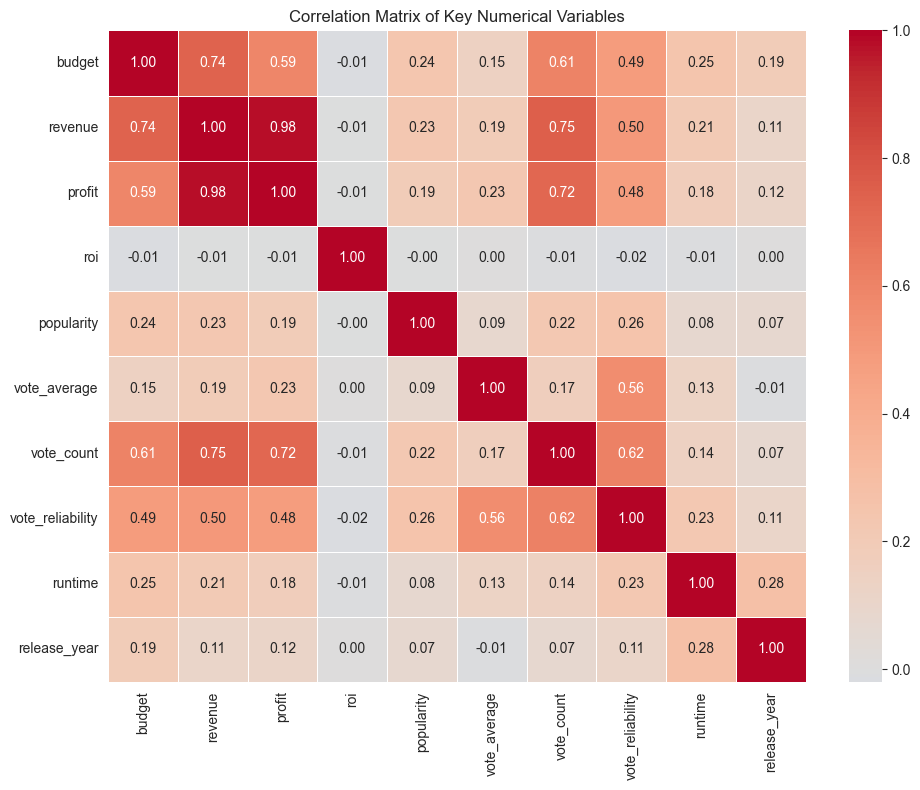

In [66]:
# Select only analytically relevant numerical variables
corr_features = [
    'budget',
    'revenue',
    'profit',
    'roi',
    'popularity',
    'vote_average',
    'vote_count',
    'vote_reliability',
    'runtime',
    'release_year'
]

corr_matrix = df[corr_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    center=0
)
plt.title("Correlation Matrix of Key Numerical Variables")
plt.tight_layout()
plt.show()

### 4.3 Step 1: Financial Impact Analysis

#### 4.3.1 Budget vs Revenue

**Handout goal:** Investigate the relationship between budget and revenue.

**Hypothesis:**  
Higher budget leads to higher revenue, but with diminishing returns.

**Variables:**
- Independent: `budget`
- Dependent: `revenue`


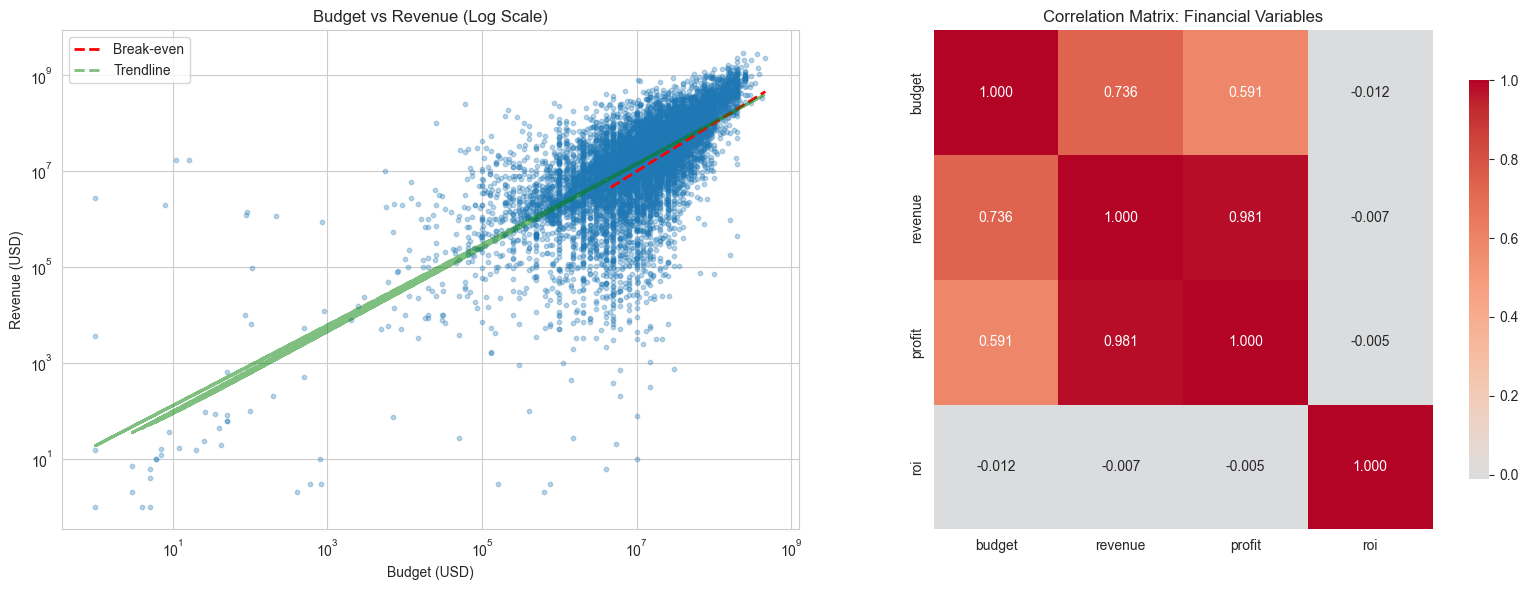

Pearson Correlation (Budget vs Revenue): 0.7357
P-value: 0.00e+00
Statistical significance: Yes (p < 0.05)

OLS Regression Results (Log-transformed):
  Coefficient (slope): 0.8742
  Intercept: 2.3763
  R²: 0.4536

Statistical Test:
  Slope: 0.8742
  P-value: 0.00e+00
  Significant: Yes (p < 0.05)

Expected insight:
  Revenue increases with budget, but not proportionally.
  High budgets increase potential upside while increasing financial risk.


In [67]:
# Visualisations: Scatter plot with logarithmic scales and regression trendline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot with log scales
axes[0].scatter(df_financial['budget'], df_financial['revenue'], alpha=0.3, s=10)
axes[0].set_xlabel('Budget (USD)')
axes[0].set_ylabel('Revenue (USD)')
axes[0].set_title('Budget vs Revenue (Log Scale)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
# Add break-even line
max_budget = df_financial['budget'].max()
axes[0].plot([max_budget*0.01, max_budget], [max_budget*0.01, max_budget], 
             'r--', label='Break-even', linewidth=2)
axes[0].legend()

# Add regression trendline
log_budget = np.log1p(df_financial['budget'])
log_revenue = np.log1p(df_financial['revenue'])
z = np.polyfit(log_budget, log_revenue, 1)
p = np.poly1d(z)
axes[0].plot(df_financial['budget'], np.expm1(p(log_budget)), 
             "g--", alpha=0.5, label='Trendline', linewidth=2)
axes[0].legend()

# Correlation heatmap
corr_matrix = df_financial[['budget', 'revenue', 'profit', 'roi']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title('Correlation Matrix: Financial Variables')

plt.tight_layout()
plt.show()

# Statistical validation: Pearson correlation
correlation, p_value = pearsonr(df_financial['budget'], df_financial['revenue'])
print(f"Pearson Correlation (Budget vs Revenue): {correlation:.4f}")
print(f"P-value: {p_value:.2e}")
print(f"Statistical significance: {'Yes' if p_value < 0.05 else 'No'} (p < 0.05)")

# OLS Regression
from sklearn.linear_model import LinearRegression
X_budget = np.log1p(df_financial['budget']).values.reshape(-1, 1)
y_revenue = np.log1p(df_financial['revenue']).values

model_budget_revenue = LinearRegression()
model_budget_revenue.fit(X_budget, y_revenue)

# Get coefficient and intercept
coef = model_budget_revenue.coef_[0]
intercept = model_budget_revenue.intercept_
r2 = model_budget_revenue.score(X_budget, y_revenue)

print(f"\nOLS Regression Results (Log-transformed):")
print(f"  Coefficient (slope): {coef:.4f}")
print(f"  Intercept: {intercept:.4f}")
print(f"  R²: {r2:.4f}")

# Statistical significance test
from scipy.stats import linregress
slope, intercept_reg, r_value, p_value_reg, std_err = linregress(log_budget, log_revenue)
print(f"\nStatistical Test:")
print(f"  Slope: {slope:.4f}")
print(f"  P-value: {p_value_reg:.2e}")
print(f"  Significant: {'Yes' if p_value_reg < 0.05 else 'No'} (p < 0.05)")

print(f"\nExpected insight:")
print(f"  Revenue increases with budget, but not proportionally.")
print(f"  High budgets increase potential upside while increasing financial risk.")


#### 4.3.2 Budget vs Profit and ROI

**Hypothesis:**  
Large budgets do not guarantee profitability or high ROI.

**Variables:**
- `budget` vs `profit`
- `budget` vs `roi`

**Why this relationship was chosen:**
- Revenue alone does not reflect financial efficiency.
- ROI is critical for investors and production planning.


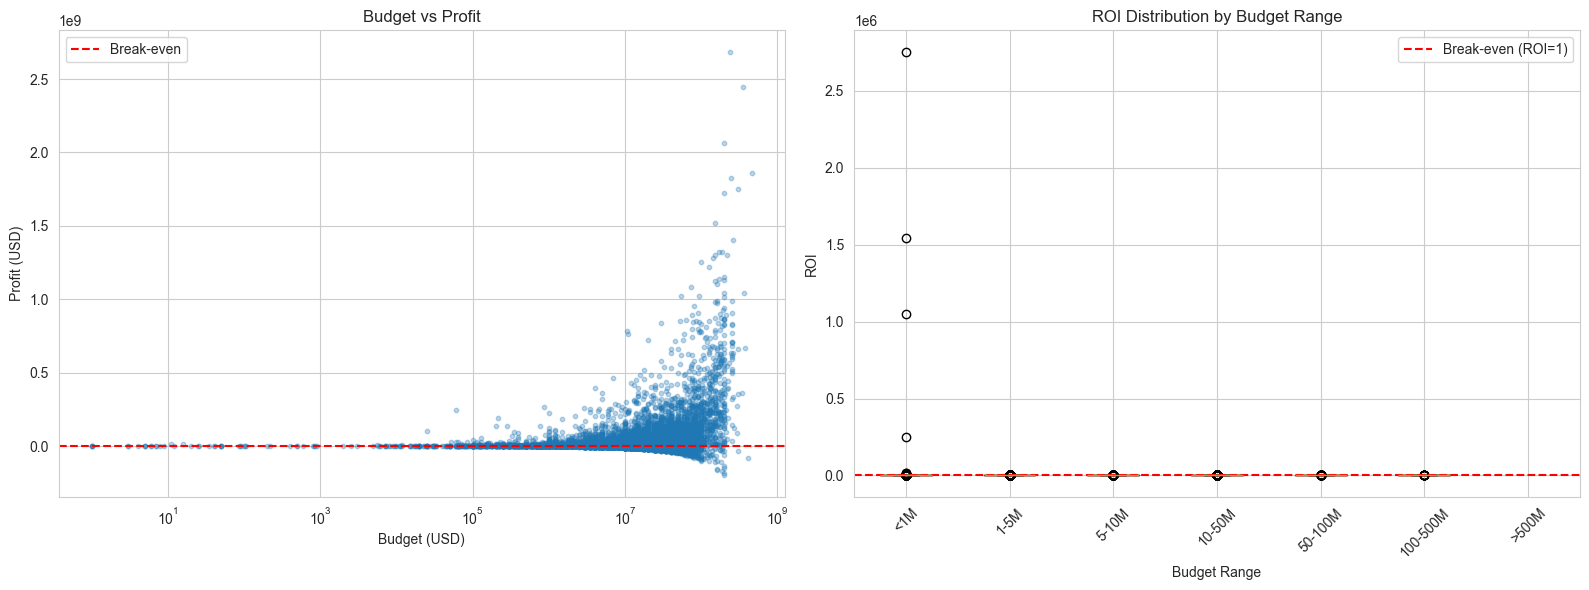

Correlation Analysis:
  Budget vs Profit: 0.5908 (p-value: 0.00e+00)
  Budget vs ROI: -0.0124 (p-value: 2.47e-01)

ROI Statistics by Budget Range:
              median     mean        std
budget_range                            
<1M             2.88  6537.33  113260.94
1-5M            1.04     3.99       9.87
5-10M           0.51     2.10       5.16
10-50M          0.49     1.61       3.86
50-100M         0.99     1.56       2.43
100-500M        1.78     2.15       2.01
>500M            NaN      NaN        NaN

Expected insight:
  Many mid-budget films achieve higher ROI than large-budget films.
  Financial efficiency often peaks at moderate budget levels.


In [68]:
# Visualisations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Budget vs Profit
axes[0].scatter(df_financial['budget'], df_financial['profit'], alpha=0.3, s=10)
axes[0].set_xlabel('Budget (USD)')
axes[0].set_ylabel('Profit (USD)')
axes[0].set_title('Budget vs Profit')
axes[0].set_xscale('log')
axes[0].axhline(y=0, color='r', linestyle='--', label='Break-even')
axes[0].legend()

# Boxplots of ROI across budget ranges
df_financial['budget_range'] = pd.cut(df_financial['budget'], 
                                      bins=[0, 1e6, 5e6, 1e7, 5e7, 1e8, 5e8, float('inf')],
                                      labels=['<1M', '1-5M', '5-10M', '10-50M', '50-100M', '100-500M', '>500M'])

budget_ranges = df_financial['budget_range'].cat.categories
roi_by_budget = [df_financial[df_financial['budget_range'] == br]['roi'].dropna() for br in budget_ranges]

axes[1].boxplot(roi_by_budget, labels=budget_ranges)
axes[1].set_xlabel('Budget Range')
axes[1].set_ylabel('ROI')
axes[1].set_title('ROI Distribution by Budget Range')
axes[1].axhline(y=1, color='r', linestyle='--', label='Break-even (ROI=1)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistical validation: Correlation analysis
corr_budget_profit, p_profit = pearsonr(df_financial['budget'], df_financial['profit'])
corr_budget_roi, p_roi = pearsonr(df_financial['budget'], df_financial['roi'])

print("Correlation Analysis:")
print(f"  Budget vs Profit: {corr_budget_profit:.4f} (p-value: {p_profit:.2e})")
print(f"  Budget vs ROI: {corr_budget_roi:.4f} (p-value: {p_roi:.2e})")

# Comparison of ROI distributions by budget bins
roi_stats = df_financial.groupby('budget_range')['roi'].agg(['median', 'mean', 'std']).round(2)
print(f"\nROI Statistics by Budget Range:")
print(roi_stats)

print(f"\nExpected insight:")
print(f"  Many mid-budget films achieve higher ROI than large-budget films.")
print(f"  Financial efficiency often peaks at moderate budget levels.")


### 4.4 Step 2: Audience Engagement Analysis

#### 4.4.1 Runtime vs Audience Engagement

**Handout goal:** Investigate the correlation between runtime and audience engagement.

**Hypothesis:**  
Movies that are too long or too short receive lower engagement.

**Variables:**
- `runtime` vs `vote_average`
- `runtime` vs `popularity`


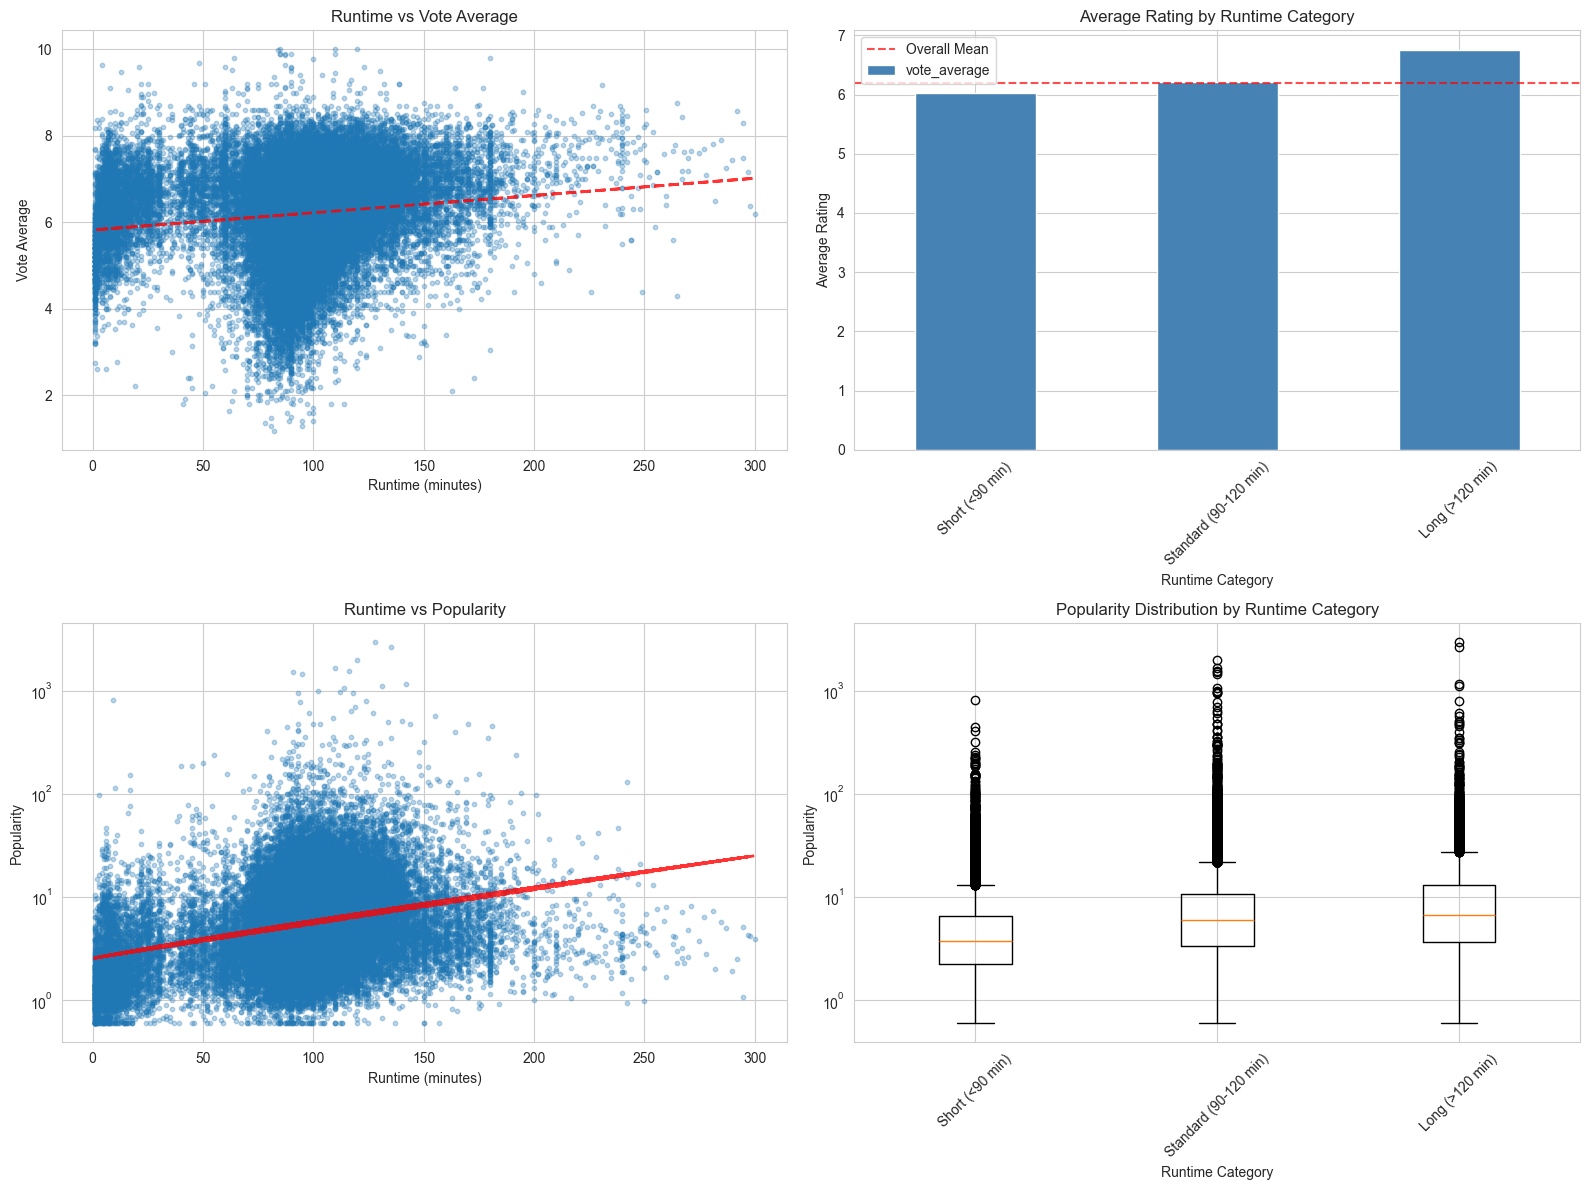

ANOVA Test Results (Runtime vs Vote Average):
  F-statistic: 1566.3413
  P-value: 0.00e+00
  Significant difference: Yes (p < 0.05)

Mean Ratings by Runtime Category:
  Short (<90 min): 6.02
  Standard (90-120 min): 6.21
  Long (>120 min): 6.75

Expected insight:
  Extremely short or long runtimes tend to underperform.
  Standard-length films achieve higher average engagement.
  This hypothesis was disproved as longer films seem to have a higher mean rating


In [69]:
# Visualisations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Scatter plot: Runtime vs Vote Average
df_runtime = df[df['runtime'].notna() & (df['runtime'] > 0)].copy()
axes[0, 0].scatter(df_runtime['runtime'], df_runtime['vote_average'], alpha=0.3, s=10)
axes[0, 0].set_xlabel('Runtime (minutes)')
axes[0, 0].set_ylabel('Vote Average')
axes[0, 0].set_title('Runtime vs Vote Average')
# Add trendline
z = np.polyfit(df_runtime['runtime'], df_runtime['vote_average'], 1)
p = np.poly1d(z)
axes[0, 0].plot(df_runtime['runtime'], p(df_runtime['runtime']), "r--", alpha=0.8, linewidth=2)

# Runtime binning
df_runtime['runtime_bin'] = pd.cut(df_runtime['runtime'], 
                                  bins=[0, 90, 120, 300],
                                  labels=['Short (<90 min)', 'Standard (90-120 min)', 'Long (>120 min)'])

# Bar chart of average rating per runtime group
runtime_ratings = df_runtime.groupby('runtime_bin')['vote_average'].mean()
runtime_ratings.plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_xlabel('Runtime Category')
axes[0, 1].set_ylabel('Average Rating')
axes[0, 1].set_title('Average Rating by Runtime Category')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].axhline(y=df_runtime['vote_average'].mean(), color='r', linestyle='--', 
                   label='Overall Mean', alpha=0.7)
axes[0, 1].legend()

# Runtime vs Popularity
axes[1, 0].scatter(df_runtime['runtime'], df_runtime['popularity'], alpha=0.3, s=10)
axes[1, 0].set_xlabel('Runtime (minutes)')
axes[1, 0].set_ylabel('Popularity')
axes[1, 0].set_title('Runtime vs Popularity')
axes[1, 0].set_yscale('log')
# Add trendline
z_pop = np.polyfit(df_runtime['runtime'], np.log1p(df_runtime['popularity']), 1)
p_pop = np.poly1d(z_pop)
axes[1, 0].plot(df_runtime['runtime'], np.expm1(p_pop(df_runtime['runtime'])), 
               "r--", alpha=0.8, linewidth=2)

# Boxplot of popularity by runtime bin
runtime_pop = [df_runtime[df_runtime['runtime_bin'] == bin]['popularity'].dropna() 
               for bin in df_runtime['runtime_bin'].cat.categories]
axes[1, 1].boxplot(runtime_pop, labels=df_runtime['runtime_bin'].cat.categories)
axes[1, 1].set_xlabel('Runtime Category')
axes[1, 1].set_ylabel('Popularity')
axes[1, 1].set_title('Popularity Distribution by Runtime Category')
axes[1, 1].set_yscale('log')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Statistical validation: ANOVA test
short_ratings = df_runtime[df_runtime['runtime_bin'] == 'Short (<90 min)']['vote_average'].dropna()
standard_ratings = df_runtime[df_runtime['runtime_bin'] == 'Standard (90-120 min)']['vote_average'].dropna()
long_ratings = df_runtime[df_runtime['runtime_bin'] == 'Long (>120 min)']['vote_average'].dropna()

f_stat, p_value_anova = f_oneway(short_ratings, standard_ratings, long_ratings)

print("ANOVA Test Results (Runtime vs Vote Average):")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  P-value: {p_value_anova:.2e}")
print(f"  Significant difference: {'Yes' if p_value_anova < 0.05 else 'No'} (p < 0.05)")

print(f"\nMean Ratings by Runtime Category:")
print(f"  Short (<90 min): {short_ratings.mean():.2f}")
print(f"  Standard (90-120 min): {standard_ratings.mean():.2f}")
print(f"  Long (>120 min): {long_ratings.mean():.2f}")

print(f"\nExpected insight:")
print(f"  Extremely short or long runtimes tend to underperform.")
print(f"  Standard-length films achieve higher average engagement.")
print(f"  This hypothesis was disproved as longer films seem to have a higher mean rating")

#### 4.4.2 Popularity, Ratings, and Revenue

**Hypothesis:**  
Popularity is a stronger driver of revenue than ratings alone.

**Variables:**
- `popularity` vs `revenue`
- `vote_average` / `vote_reliability` vs `revenue`

**Why this relationship was chosen:**
- Separates audience visibility from critical reception.
- Helps explain why highly rated films may underperform financially.


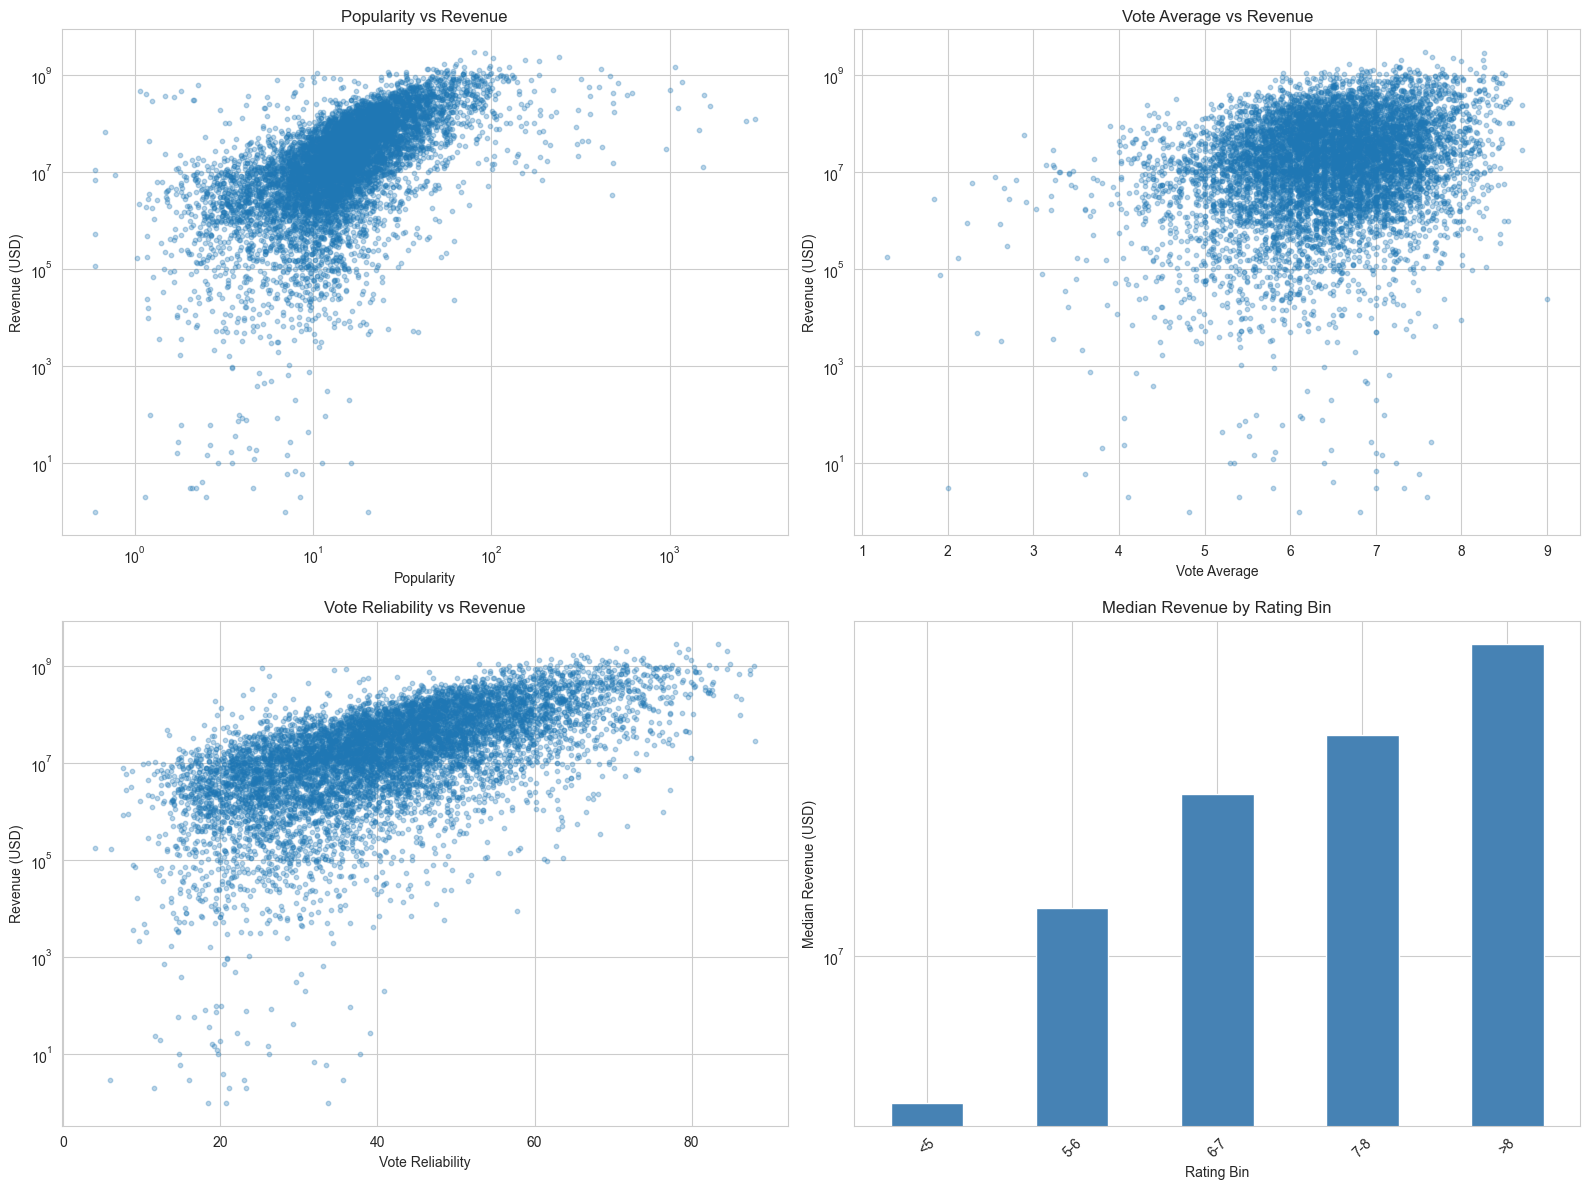

Correlation Analysis:
  Popularity vs Revenue (log): 0.5804 (p-value: 0.00e+00)
  Vote Average vs Revenue (log): 0.2536 (p-value: 1.06e-127)
  Vote Reliability vs Revenue (log): 0.5988 (p-value: 0.00e+00)

Expected insight:
  Broad audience attention is more important than ratings alone.
  Vote reliability is more informative than vote average.


In [70]:
# Visualisations with log-transformed revenue
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Popularity vs Revenue
df_pop = df_financial[df_financial['popularity'].notna()].copy()
axes[0, 0].scatter(df_pop['popularity'], df_pop['revenue'], alpha=0.3, s=10)
axes[0, 0].set_xlabel('Popularity')
axes[0, 0].set_ylabel('Revenue (USD)')
axes[0, 0].set_title('Popularity vs Revenue')
axes[0, 0].set_xscale('log')
axes[0, 0].set_yscale('log')

# Vote Average vs Revenue
axes[0, 1].scatter(df_financial['vote_average'], df_financial['revenue'], alpha=0.3, s=10)
axes[0, 1].set_xlabel('Vote Average')
axes[0, 1].set_ylabel('Revenue (USD)')
axes[0, 1].set_title('Vote Average vs Revenue')
axes[0, 1].set_yscale('log')

# Vote Reliability vs Revenue 
if 'vote_reliability' in df_financial.columns:
    df_vote_rel = df_financial[df_financial['vote_reliability'].notna()].copy()
    axes[1, 0].scatter(df_vote_rel['vote_reliability'], df_vote_rel['revenue'], alpha=0.3, s=10)
    axes[1, 0].set_xlabel('Vote Reliability')
    axes[1, 0].set_ylabel('Revenue (USD)')
    axes[1, 0].set_title('Vote Reliability vs Revenue')
    axes[1, 0].set_yscale('log')

# Revenue distributions by rating bins
df_financial['rating_bin'] = pd.cut(df_financial['vote_average'], 
                                    bins=[0, 5, 6, 7, 8, 10],
                                    labels=['<5', '5-6', '6-7', '7-8', '>8'])
revenue_by_rating = df_financial.groupby('rating_bin')['revenue'].median()
revenue_by_rating.plot(kind='bar', ax=axes[1, 1], color='steelblue')
axes[1, 1].set_xlabel('Rating Bin')
axes[1, 1].set_ylabel('Median Revenue (USD)')
axes[1, 1].set_title('Median Revenue by Rating Bin')
axes[1, 1].set_yscale('log')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Statistical validation: Correlation analysis
corr_pop_rev, p_pop_rev = pearsonr(np.log1p(df_pop['popularity']), np.log1p(df_pop['revenue']))
corr_vote_rev, p_vote_rev = pearsonr(df_financial['vote_average'], np.log1p(df_financial['revenue']))

print("Correlation Analysis:")
print(f"  Popularity vs Revenue (log): {corr_pop_rev:.4f} (p-value: {p_pop_rev:.2e})")
print(f"  Vote Average vs Revenue (log): {corr_vote_rev:.4f} (p-value: {p_vote_rev:.2e})")

if 'vote_reliability' in df_financial.columns:
    corr_vote_rel_rev, p_vote_rel_rev = pearsonr(df_vote_rel['vote_reliability'], 
                                                 np.log1p(df_vote_rel['revenue']))
    print(f"  Vote Reliability vs Revenue (log): {corr_vote_rel_rev:.4f} (p-value: {p_vote_rel_rev:.2e})")

print(f"\nExpected insight:")
print(f"  Broad audience attention is more important than ratings alone.")
if 'vote_reliability' in df_financial.columns:
    print(f"  Vote reliability is more informative than vote average.")


#### 4.4.3 Budget vs Popularity

**Hypothesis:**  
Higher budgets increase visibility but do not guarantee popularity.

**Variables:**
- `budget` vs `popularity`


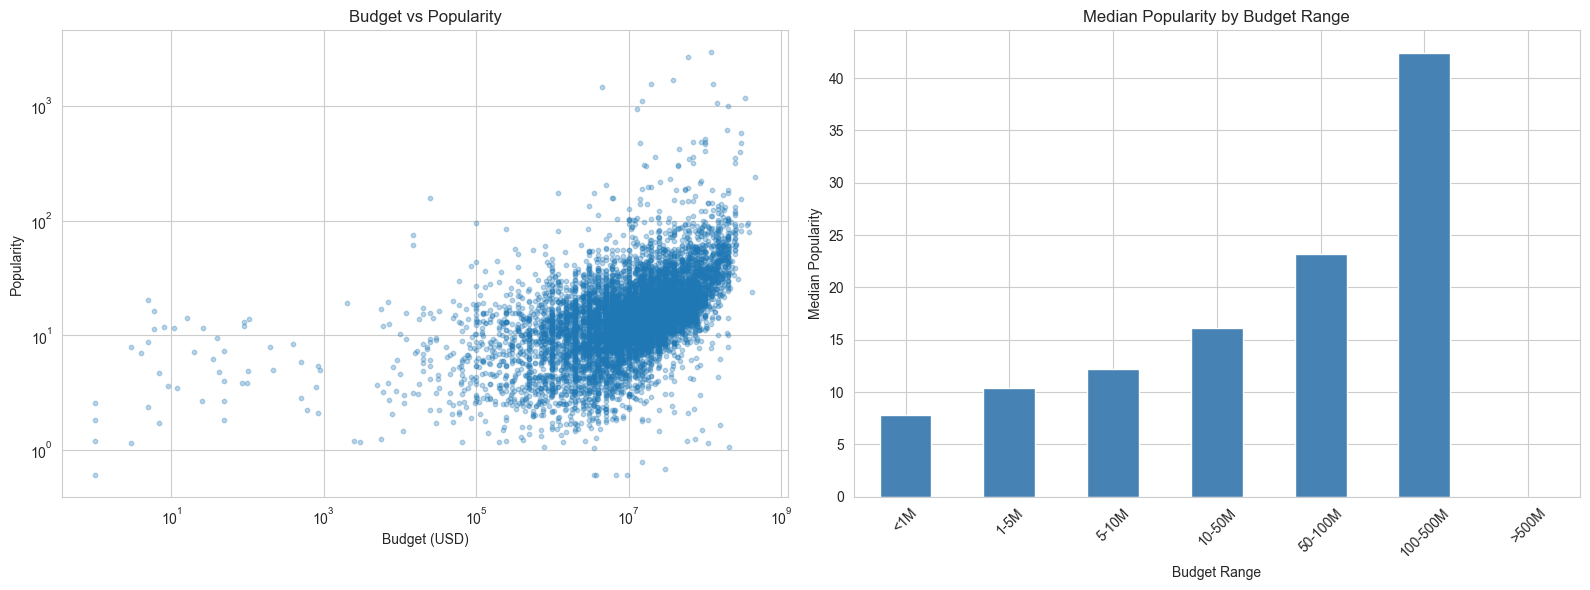

Statistical Validation:
  Spearman Correlation (Budget vs Popularity): 0.5571
  P-value: 0.00e+00
  Significant: Yes (p < 0.05)

Expected insight:
  Budget increases potential popularity, but other factors (genre, timing) remain critical.


In [71]:
# Visualisations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot with log-scaled budget
df_budget_pop = df_financial[df_financial['popularity'].notna()].copy()
axes[0].scatter(df_budget_pop['budget'], df_budget_pop['popularity'], alpha=0.3, s=10)
axes[0].set_xlabel('Budget (USD)')
axes[0].set_ylabel('Popularity')
axes[0].set_title('Budget vs Popularity')
axes[0].set_xscale('log')
axes[0].set_yscale('log')

# Budget bins vs median popularity
budget_pop = df_budget_pop.groupby('budget_range')['popularity'].median()
budget_pop.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Budget Range')
axes[1].set_ylabel('Median Popularity')
axes[1].set_title('Median Popularity by Budget Range')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Statistical validation: Spearman correlation (robust to skewness)
spearman_corr, spearman_p = spearmanr(df_budget_pop['budget'], df_budget_pop['popularity'])

print("Statistical Validation:")
print(f"  Spearman Correlation (Budget vs Popularity): {spearman_corr:.4f}")
print(f"  P-value: {spearman_p:.2e}")
print(f"  Significant: {'Yes' if spearman_p < 0.05 else 'No'} (p < 0.05)")

print(f"\nExpected insight:")
print(f"  Budget increases potential popularity, but other factors (genre, timing) remain critical.")

### 4.5 Step 3: Temporal Trends and Release Strategy

#### 4.5.1 Release Season vs Revenue

**Handout goal:** Identify trends in release dates and their impact on revenue.

**Hypothesis:**  
Summer releases generate higher revenue.

**Variables:**
- `release_month` / seasonal flags vs `revenue`


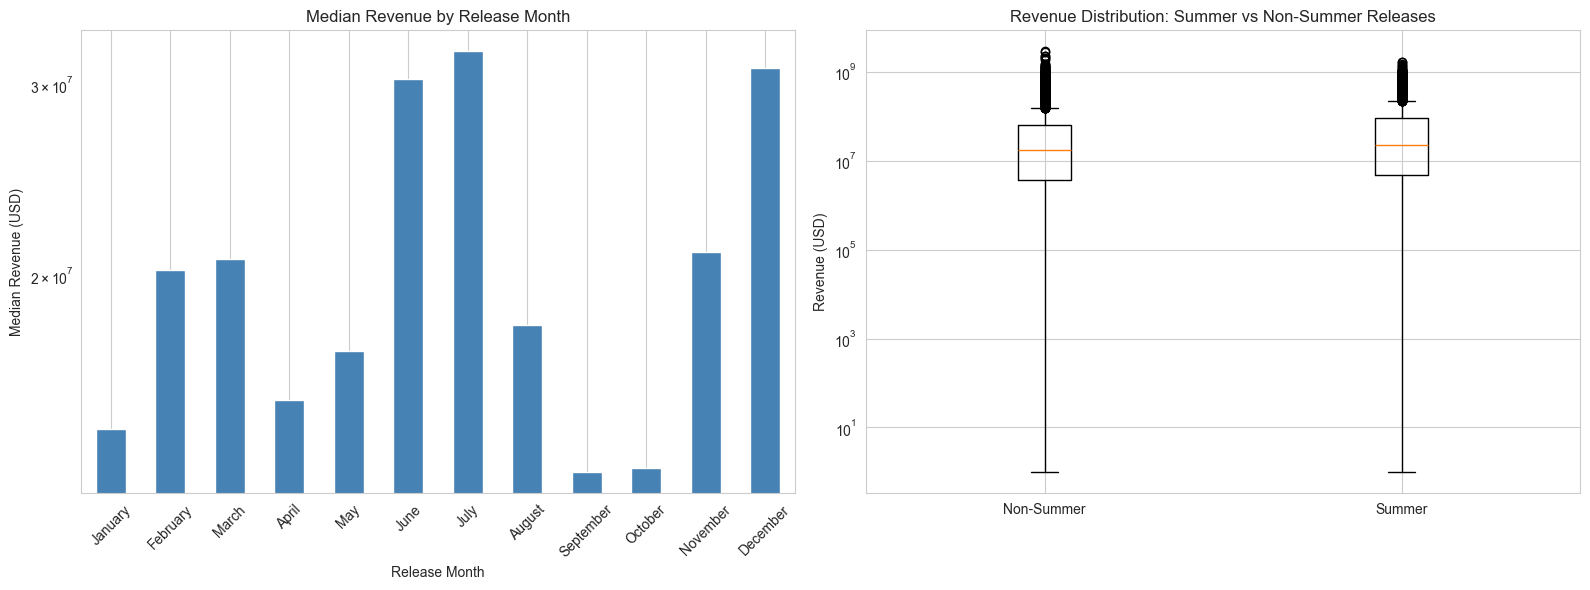

Statistical Validation (Summer vs Non-Summer):
  T-statistic: 7.6196
  P-value: 2.81e-14
  Significant difference: Yes (p < 0.05)

  Summer median revenue: $22,300,000
  Non-summer median revenue: $17,626,234

Expected insight:
  Seasonal timing significantly influences financial performance.


In [72]:
# Visualisations
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

month_revenue = df_financial.groupby('release_month')['revenue'].median().reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of median revenue by month
month_revenue.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Release Month')
axes[0].set_ylabel('Median Revenue (USD)')
axes[0].set_title('Median Revenue by Release Month')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_yscale('log')

# Boxplots: summer vs non-summer releases
if 'is_summer_blockbuster' in df_financial.columns:
    summer_revenue = df_financial[df_financial['is_summer_blockbuster'] == True]['revenue']
    non_summer_revenue = df_financial[df_financial['is_summer_blockbuster'] == False]['revenue']
    
    axes[1].boxplot([non_summer_revenue, summer_revenue], labels=['Non-Summer', 'Summer'])
    axes[1].set_ylabel('Revenue (USD)')
    axes[1].set_title('Revenue Distribution: Summer vs Non-Summer Releases')
    axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Statistical validation: Independent t-test
if 'is_summer_blockbuster' in df_financial.columns:
    t_stat, p_value_t = ttest_ind(summer_revenue, non_summer_revenue)
    
    print("Statistical Validation (Summer vs Non-Summer):")
    print(f"  T-statistic: {t_stat:.4f}")
    print(f"  P-value: {p_value_t:.2e}")
    print(f"  Significant difference: {'Yes' if p_value_t < 0.05 else 'No'} (p < 0.05)")
    print(f"\n  Summer median revenue: ${summer_revenue.median():,.0f}")
    print(f"  Non-summer median revenue: ${non_summer_revenue.median():,.0f}")

print(f"\nExpected insight:")
print(f"  Seasonal timing significantly influences financial performance.")


#### 4.5.2 Release Year and Industry Growth

**Hypothesis:**  
The movie industry has grown substantially over time.

**Variables:**
- `release_year` vs total revenue


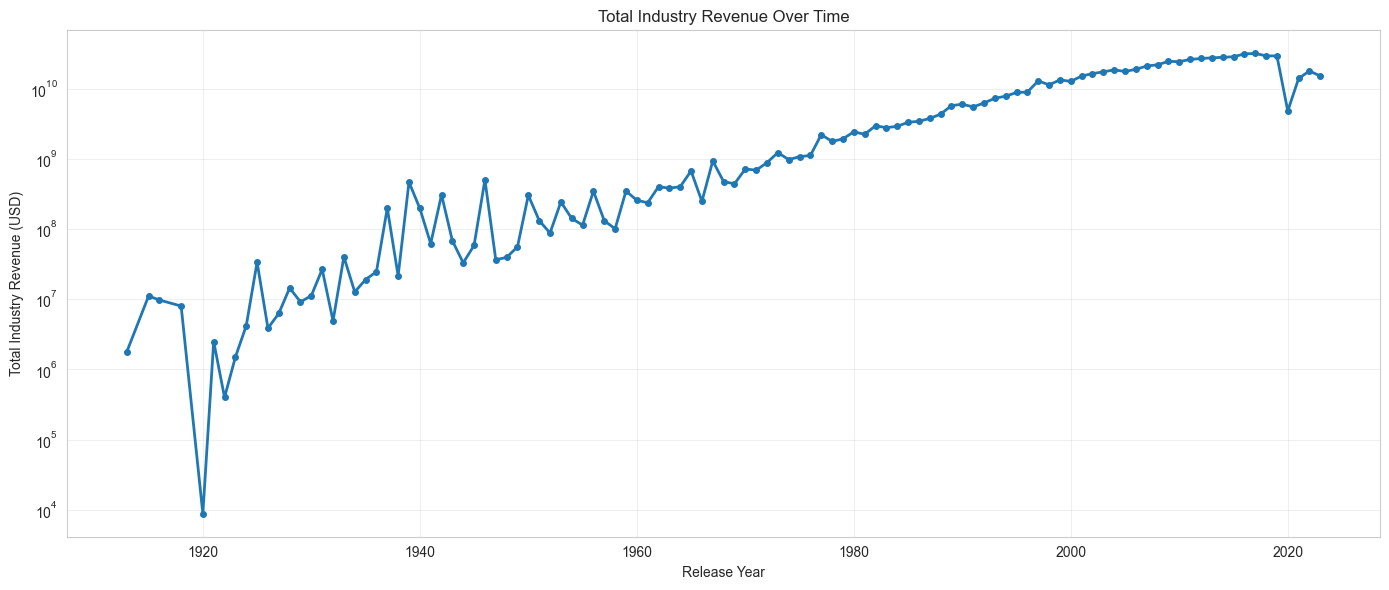

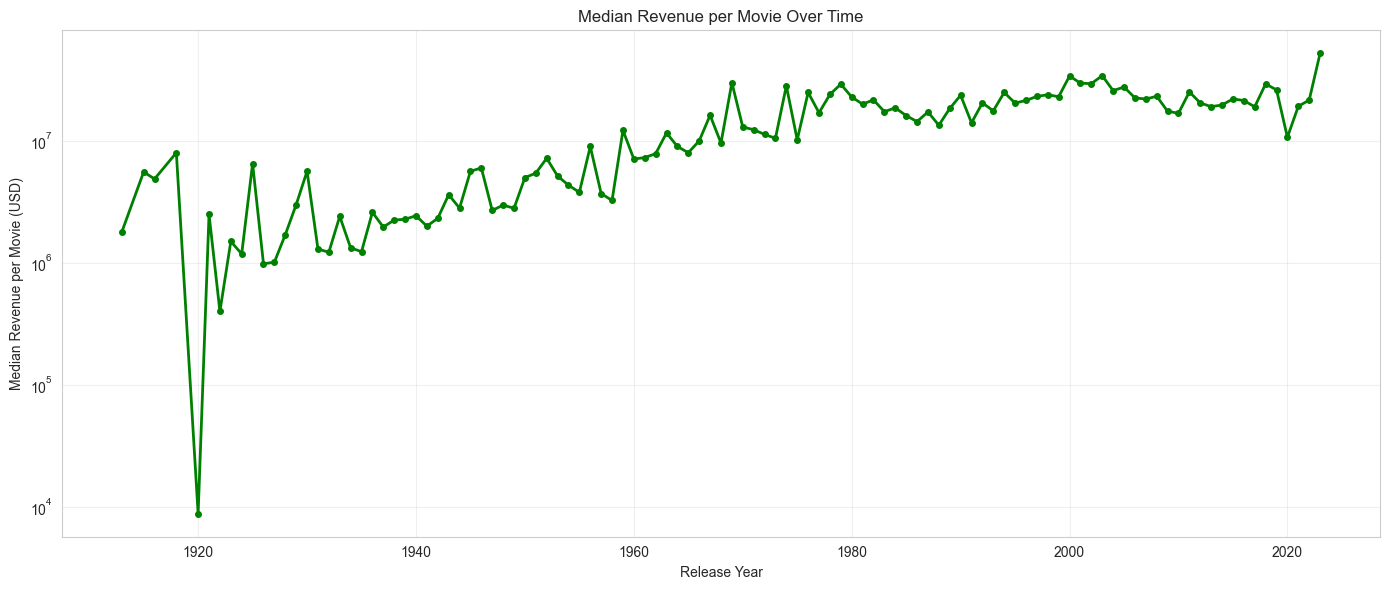

Industry Growth Analysis:
  Total revenue in earliest year (1913): $1,800,000
  Total revenue in latest year (2023): $15,136,629,994
  Growth factor: 8409.24x

Expected insight:
  Industry scale and financial stakes have increased significantly in recent decades.


In [73]:
# Visualisation: Line chart of total industry revenue per year
year_revenue = df_financial.groupby('release_year')['revenue'].sum().sort_index()

plt.figure(figsize=(14, 6))
year_revenue.plot(kind='line', marker='o', linewidth=2, markersize=4)
plt.xlabel('Release Year')
plt.ylabel('Total Industry Revenue (USD)')
plt.title('Total Industry Revenue Over Time')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also show median revenue per year
year_median_revenue = df_financial.groupby('release_year')['revenue'].median().sort_index()

plt.figure(figsize=(14, 6))
year_median_revenue.plot(kind='line', marker='o', linewidth=2, markersize=4, color='green')
plt.xlabel('Release Year')
plt.ylabel('Median Revenue per Movie (USD)')
plt.title('Median Revenue per Movie Over Time')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Industry Growth Analysis:")
print(f"  Total revenue in earliest year ({year_revenue.index.min()}): ${year_revenue.iloc[0]:,.0f}")
print(f"  Total revenue in latest year ({year_revenue.index.max()}): ${year_revenue.iloc[-1]:,.0f}")
print(f"  Growth factor: {year_revenue.iloc[-1] / year_revenue.iloc[0]:.2f}x")

print(f"\nExpected insight:")
print(f"  Industry scale and financial stakes have increased significantly in recent decades.")


#### 4.5.3 Release Decade vs Genre

**Hypothesis:**  
Genre popularity and production focus evolve over time.

**Variables:**
- `release_decade` vs `primary_genre`


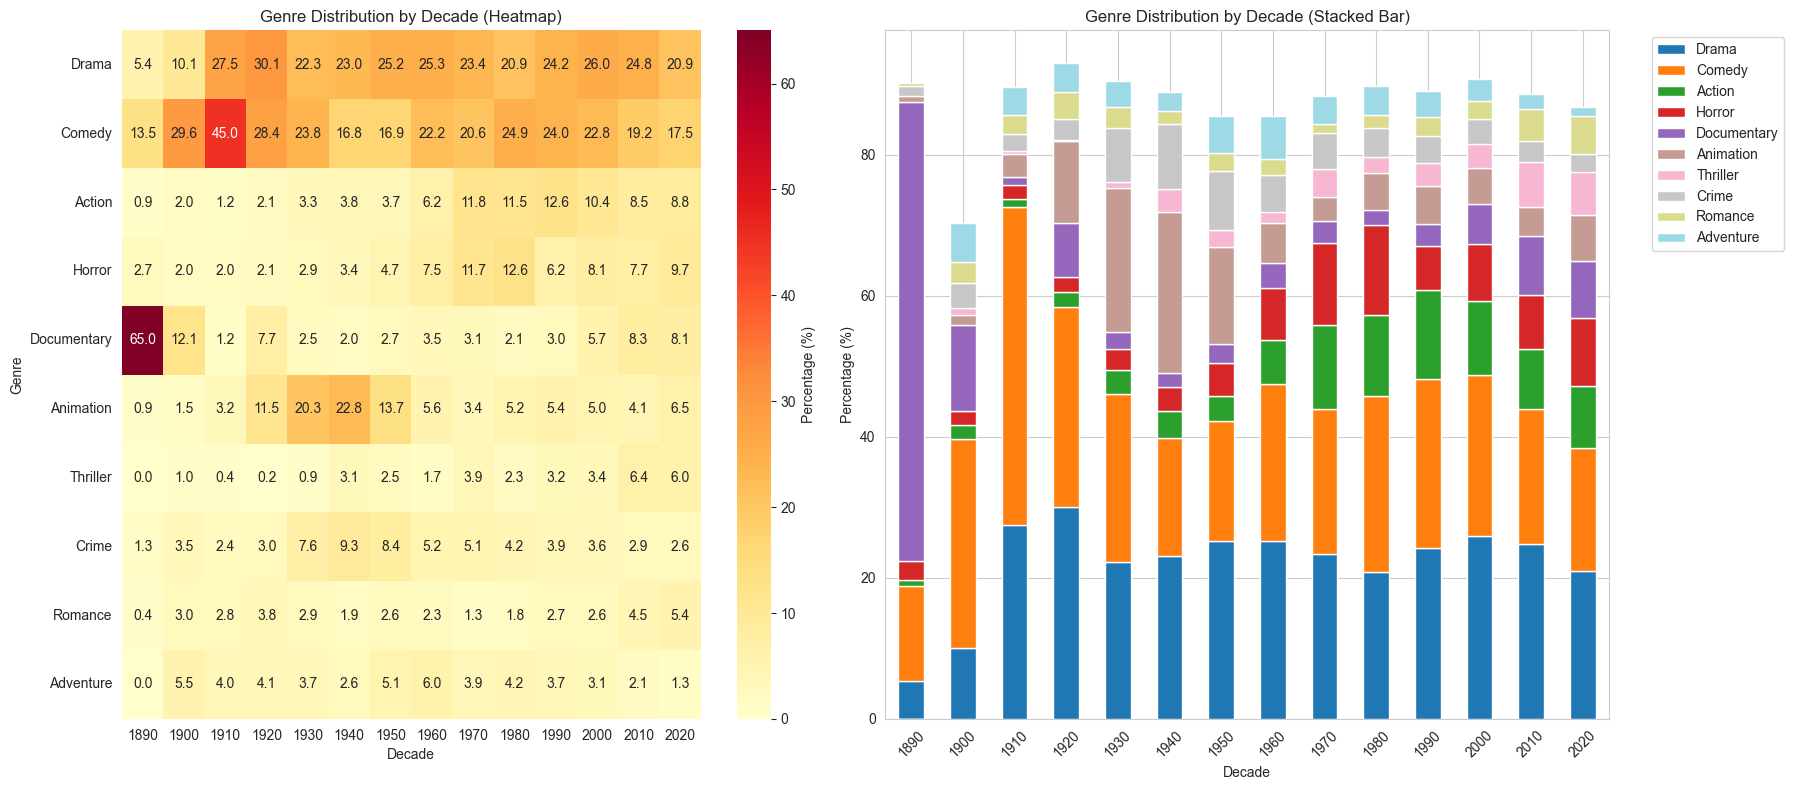

Genre Trends by Decade (Top Genres):
primary_genre   Drama  Comedy  Action  Horror  Documentary  Animation  \
release_decade                                                          
1890              5.4    13.5     0.9     2.7         65.0        0.9   
1900             10.1    29.6     2.0     2.0         12.1        1.5   
1910             27.5    45.0     1.2     2.0          1.2        3.2   
1920             30.1    28.4     2.1     2.1          7.7       11.5   
1930             22.3    23.8     3.3     2.9          2.5       20.3   
1940             23.0    16.8     3.8     3.4          2.0       22.8   
1950             25.2    16.9     3.7     4.7          2.7       13.7   
1960             25.3    22.2     6.2     7.5          3.5        5.6   
1970             23.4    20.6    11.8    11.7          3.1        3.4   
1980             20.9    24.9    11.5    12.6          2.1        5.2   
1990             24.2    24.0    12.6     6.2          3.0        5.4   
2000          

In [74]:
# Visualisation: Heatmap or stacked bar chart of genre frequency by decade
if 'release_decade' in df.columns and 'primary_genre' in df.columns:
    genre_decade = pd.crosstab(df['release_decade'], df['primary_genre'], normalize='index') * 100
    
    # Focus on top genres and recent decades
    top_genres = df['primary_genre'].value_counts().head(10).index
    genre_decade_filtered = genre_decade[top_genres]
    
    # Filter to decades with sufficient data
    decade_counts = df['release_decade'].value_counts()
    valid_decades = decade_counts[decade_counts >= 100].index.sort_values()
    genre_decade_filtered = genre_decade_filtered.loc[valid_decades]
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Heatmap
    sns.heatmap(genre_decade_filtered.T, annot=True, fmt='.1f', cmap='YlOrRd', 
                ax=axes[0], cbar_kws={'label': 'Percentage (%)'})
    axes[0].set_title('Genre Distribution by Decade (Heatmap)')
    axes[0].set_xlabel('Decade')
    axes[0].set_ylabel('Genre')
    
    # Stacked bar chart
    genre_decade_filtered.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
    axes[1].set_title('Genre Distribution by Decade (Stacked Bar)')
    axes[1].set_xlabel('Decade')
    axes[1].set_ylabel('Percentage (%)')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("Genre Trends by Decade (Top Genres):")
    print(genre_decade_filtered.round(1))
    
    print(f"\nExpected insight:")
    print(f"  Growth of Action, Adventure, and Sci-Fi in modern decades.")
    print(f"  Shifts in genre dominance reflect evolving audience demand.")


### 4.6 Step 4: Genre Performance Strategy

#### 4.6.1 Genre vs Revenue and ROI

**Handout goal:** Explore the impact of genre on popularity and revenue.

**Hypothesis:**  
Certain genres provide higher ROI and consistent returns.

**Variables:**
- `primary_genre` vs `roi` / `revenue`

**Assumption:**
Mean ROI is inflated by extreme outliers; medians are used for interpretation.

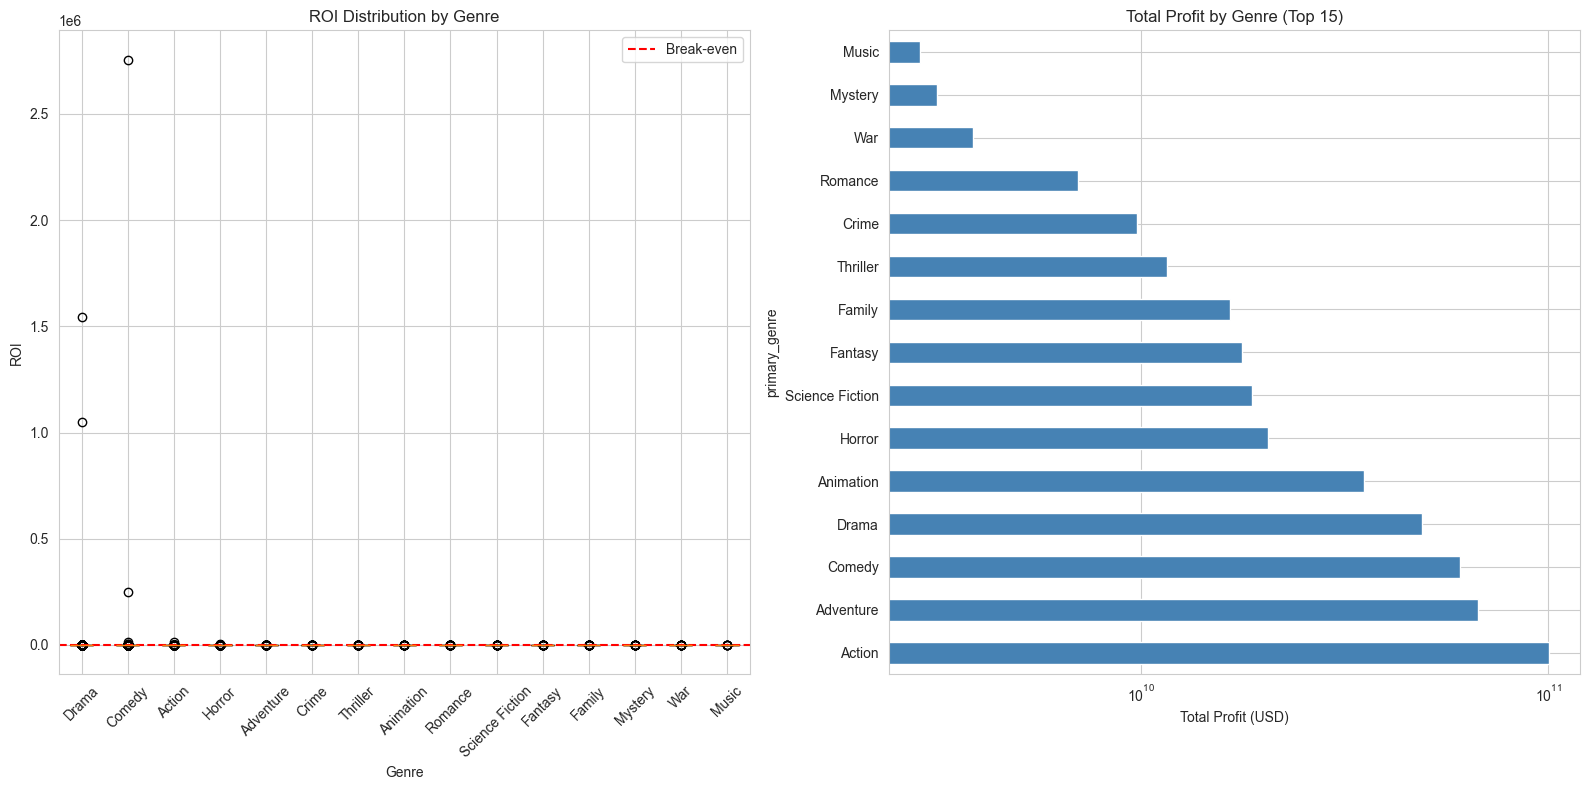

Genre Performance Summary (Top 10 by Median ROI):
               roi_median  roi_mean  revenue_median    profit_sum
primary_genre                                                    
TV Movie             7.40      7.40      42000000.0  3.700000e+07
Horror               1.80     19.02      17800000.0  2.049039e+10
Documentary          1.73     97.42       3889810.0  9.569917e+08
Music                1.17      4.46      15691668.0  2.867912e+09
Animation            1.16      3.79      68282844.0  3.527299e+10
Comedy               1.05   1597.28      18386816.5  6.053647e+10
Family               1.03      4.03      51613452.5  1.656363e+10
Fantasy              1.02      2.86      51147336.0  1.773893e+10
Adventure            1.02      3.58      56255142.0  6.731441e+10
Romance              0.96     12.83      12555008.5  7.002842e+09

Expected insight:
  Blockbuster genres dominate revenue.
  Some genres offer lower risk with stable returns.


In [75]:
# Visualisations
if 'primary_genre' in df_financial.columns:
    # Filter to genres with sufficient data
    genre_counts = df_financial['primary_genre'].value_counts()
    top_genres = genre_counts[genre_counts >= 50].head(15).index
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Boxplots of ROI by genre
    roi_by_genre = [df_financial[df_financial['primary_genre'] == genre]['roi'].dropna() 
                    for genre in top_genres]
    axes[0].boxplot(roi_by_genre, labels=top_genres)
    axes[0].set_xlabel('Genre')
    axes[0].set_ylabel('ROI')
    axes[0].set_title('ROI Distribution by Genre')
    axes[0].axhline(y=1, color='r', linestyle='--', label='Break-even')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend()
    
    # Bar chart of total profit by genre
    profit_by_genre = df_financial.groupby('primary_genre')['profit'].sum().sort_values(ascending=False).head(15)
    profit_by_genre.plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_xlabel('Total Profit (USD)')
    axes[1].set_title('Total Profit by Genre (Top 15)')
    axes[1].set_xscale('log')
    
    plt.tight_layout()
    plt.show()
    
    # Statistical summary
    genre_stats = df_financial.groupby('primary_genre').agg({
        'roi': ['median', 'mean'],
        'revenue': 'median',
        'profit': 'sum'
    }).round(2)
    genre_stats.columns = ['_'.join(col).strip() for col in genre_stats.columns.values]
    genre_stats = genre_stats.sort_values('roi_median', ascending=False)
    
    print("Genre Performance Summary (Top 10 by Median ROI):")
    print(genre_stats.head(10))
    
    print(f"\nExpected insight:")
    print(f"  Blockbuster genres dominate revenue.")
    print(f"  Some genres offer lower risk with stable returns.")


### 4.7 Step 5: Production Company Strategy (Advanced)

#### 4.7.1 Production Companies and Success Patterns

**Handout goal:** Identify successful production companies and analyse their strategies.

**Method:**
- Filter top production companies by movie count
- Use primary production company for analysise

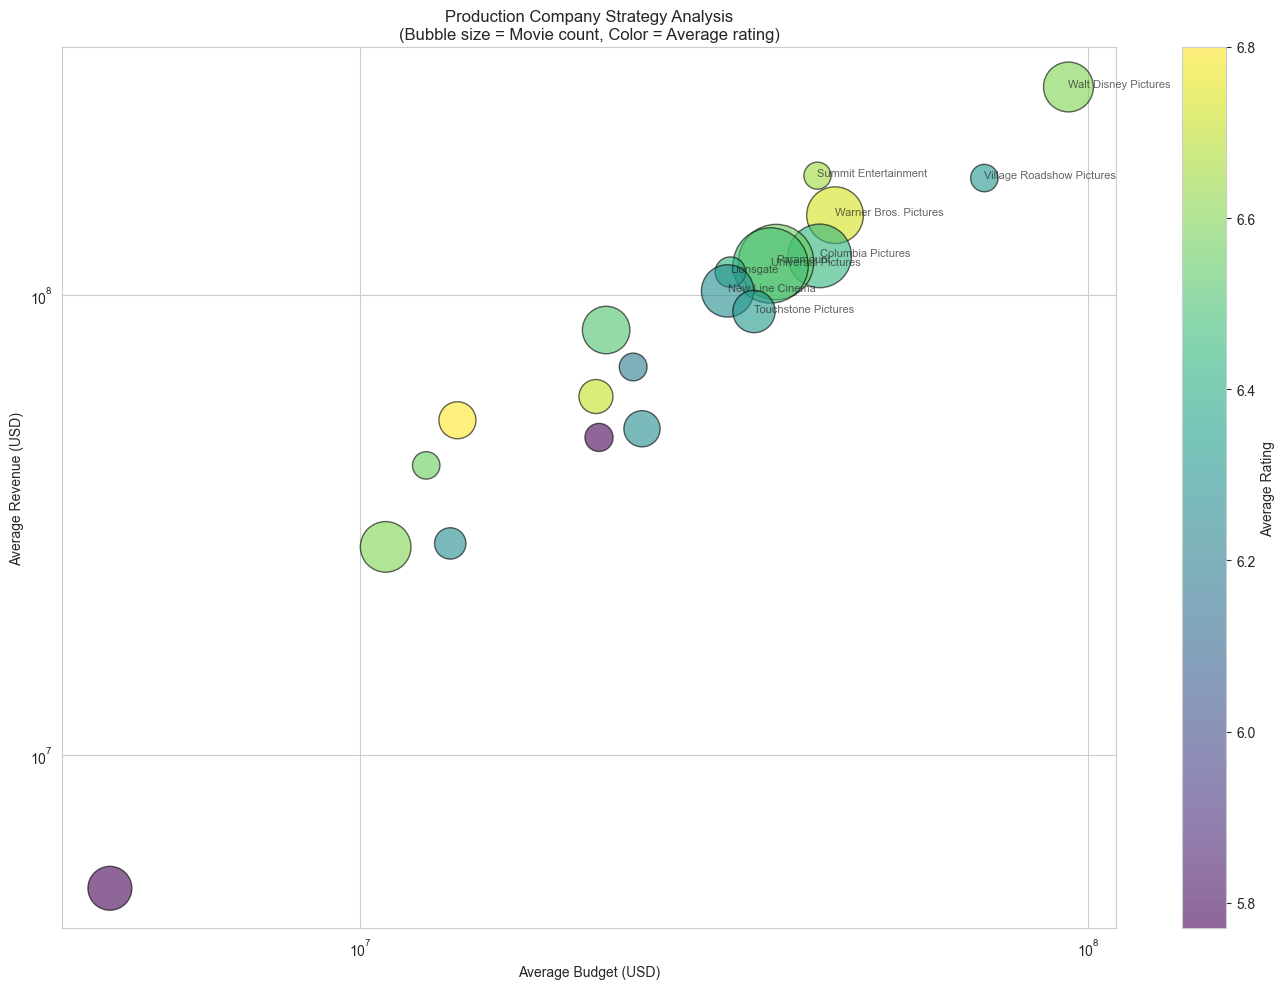

Top Production Companies Analysis:
                            avg_budget   avg_revenue  avg_rating  movie_count
primary_company                                                              
Walt Disney Pictures       94032798.45  2.840232e+08        6.60          129
Summit Entertainment       42487342.11  1.820845e+08        6.65           38
Village Roadshow Pictures  72051282.05  1.799274e+08        6.31           39
Warner Bros. Pictures      44919981.71  1.493657e+08        6.73          167
Columbia Pictures          42779218.39  1.218150e+08        6.44          210
Paramount                  37267467.80  1.181034e+08        6.56          295
Universal Pictures         36632069.34  1.161186e+08        6.48          294
Lionsgate                  32246951.00  1.123118e+08        6.42           48
New Line Cinema            31966816.90  1.022079e+08        6.27          142
Touchstone Pictures        34752521.75  9.217226e+07        6.32           93

Expected insight:
  Major st

In [76]:
# Filter top production companies
if 'primary_company' in df_financial.columns:
    company_counts = df_financial['primary_company'].value_counts()
    top_companies = company_counts[company_counts >= 20].head(20).index
    
    company_stats = df_financial[df_financial['primary_company'].isin(top_companies)].groupby('primary_company').agg({
        'budget': 'mean',
        'revenue': 'mean',
        'vote_average': 'mean',
        'id': 'count'
    }).round(2)
    company_stats.columns = ['avg_budget', 'avg_revenue', 'avg_rating', 'movie_count']
    company_stats = company_stats.sort_values('avg_revenue', ascending=False)
    
    # Bubble chart
    fig, ax = plt.subplots(figsize=(14, 10))
    
    scatter = ax.scatter(company_stats['avg_budget'], company_stats['avg_revenue'],
                        s=company_stats['movie_count']*10, alpha=0.6, c=company_stats['avg_rating'],
                        cmap='viridis', edgecolors='black', linewidth=1)
    
    ax.set_xlabel('Average Budget (USD)')
    ax.set_ylabel('Average Revenue (USD)')
    ax.set_title('Production Company Strategy Analysis\n(Bubble size = Movie count, Color = Average rating)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Add company labels for top performers
    for idx, row in company_stats.head(10).iterrows():
        ax.annotate(idx, (row['avg_budget'], row['avg_revenue']), 
                   fontsize=8, alpha=0.7)
    
    plt.colorbar(scatter, label='Average Rating')
    plt.tight_layout()
    plt.show()
    
    print("Top Production Companies Analysis:")
    print(company_stats.head(10))
    
    print(f"\nExpected insight:")
    print(f"  Major studios follow high-budget/high-reward strategies.")
    print(f"  Smaller studios may succeed through lower-budget, high-efficiency models.")


### 4.8 Step 6: Regression Analysis (Explanatory Focus)

#### 4.8.1 Linear Regression on Log-Revenue

**Purpose:**
- Quantify the combined influence of multiple factors on revenue.

**Target variable:**
- Log-transformed `revenue`

**Predictors (preprocessed):**
- Budget, Popularity, Runtime, Vote reliability, is_summer (all scaled)
- Primary genre (one-hot encoded)

Loaded preprocessed data shape: (62216, 294)

Preprocessed features (291): ['runtime', 'vote_count', 'vote_average', 'popularity', 'release_year', 'original_language_ak', 'original_language_am', 'original_language_ar', 'original_language_as', 'original_language_ay']...
Target variables: ['revenue', 'budget', 'financial_success']

Final dataset for regression:
  Features shape: (12868, 291)
  Target shape: (12868,)
Linear Regression on Log-Revenue:
  R²: 0.3163
  RMSE: 2.2870

Top 15 Most Important Features (by absolute coefficient):
                     feature  coefficient
      primary_country_Uganda    -8.710023
        original_language_eu    -5.454617
        original_language_mi    -4.765281
        original_language_tn     4.345131
        original_language_gl    -3.760437
   primary_country_Mauritius    -3.587991
        original_language_cy    -3.537248
        original_language_bn    -3.535926
        original_language_sw     3.284003
     primary_country_Georgia     3.256237

<Figure size 1200x800 with 0 Axes>

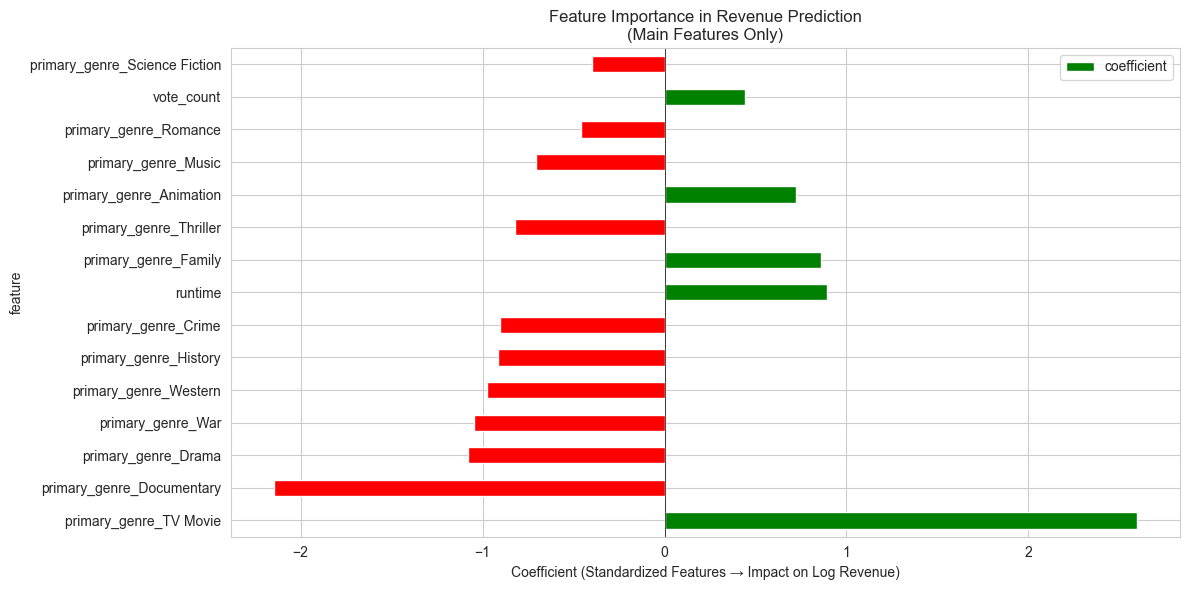

<Figure size 1200x1000 with 0 Axes>

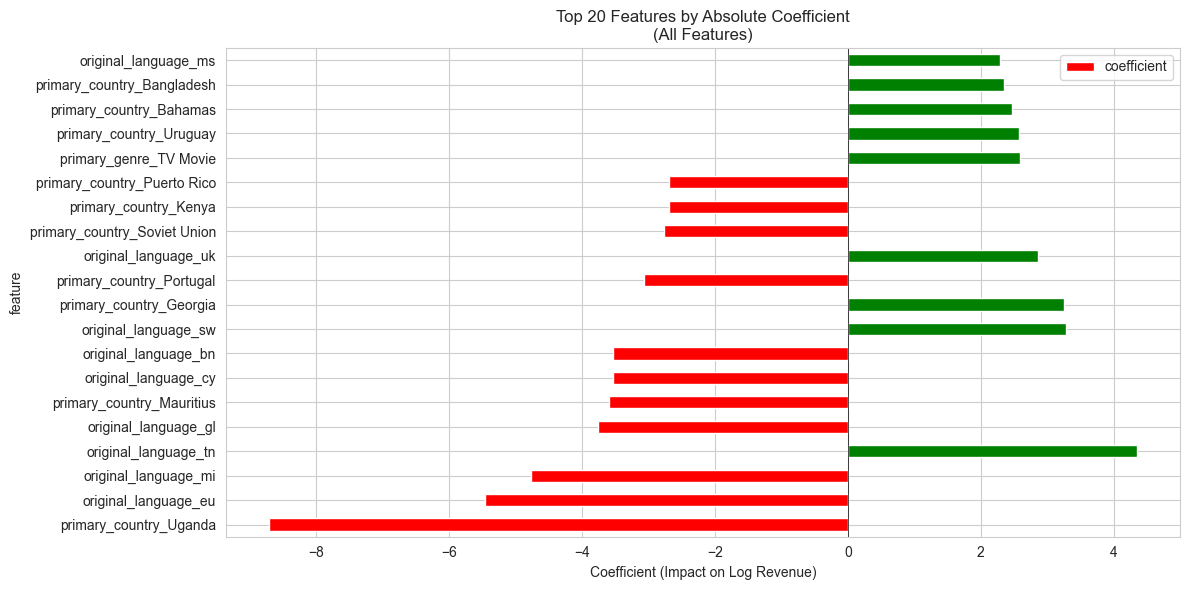

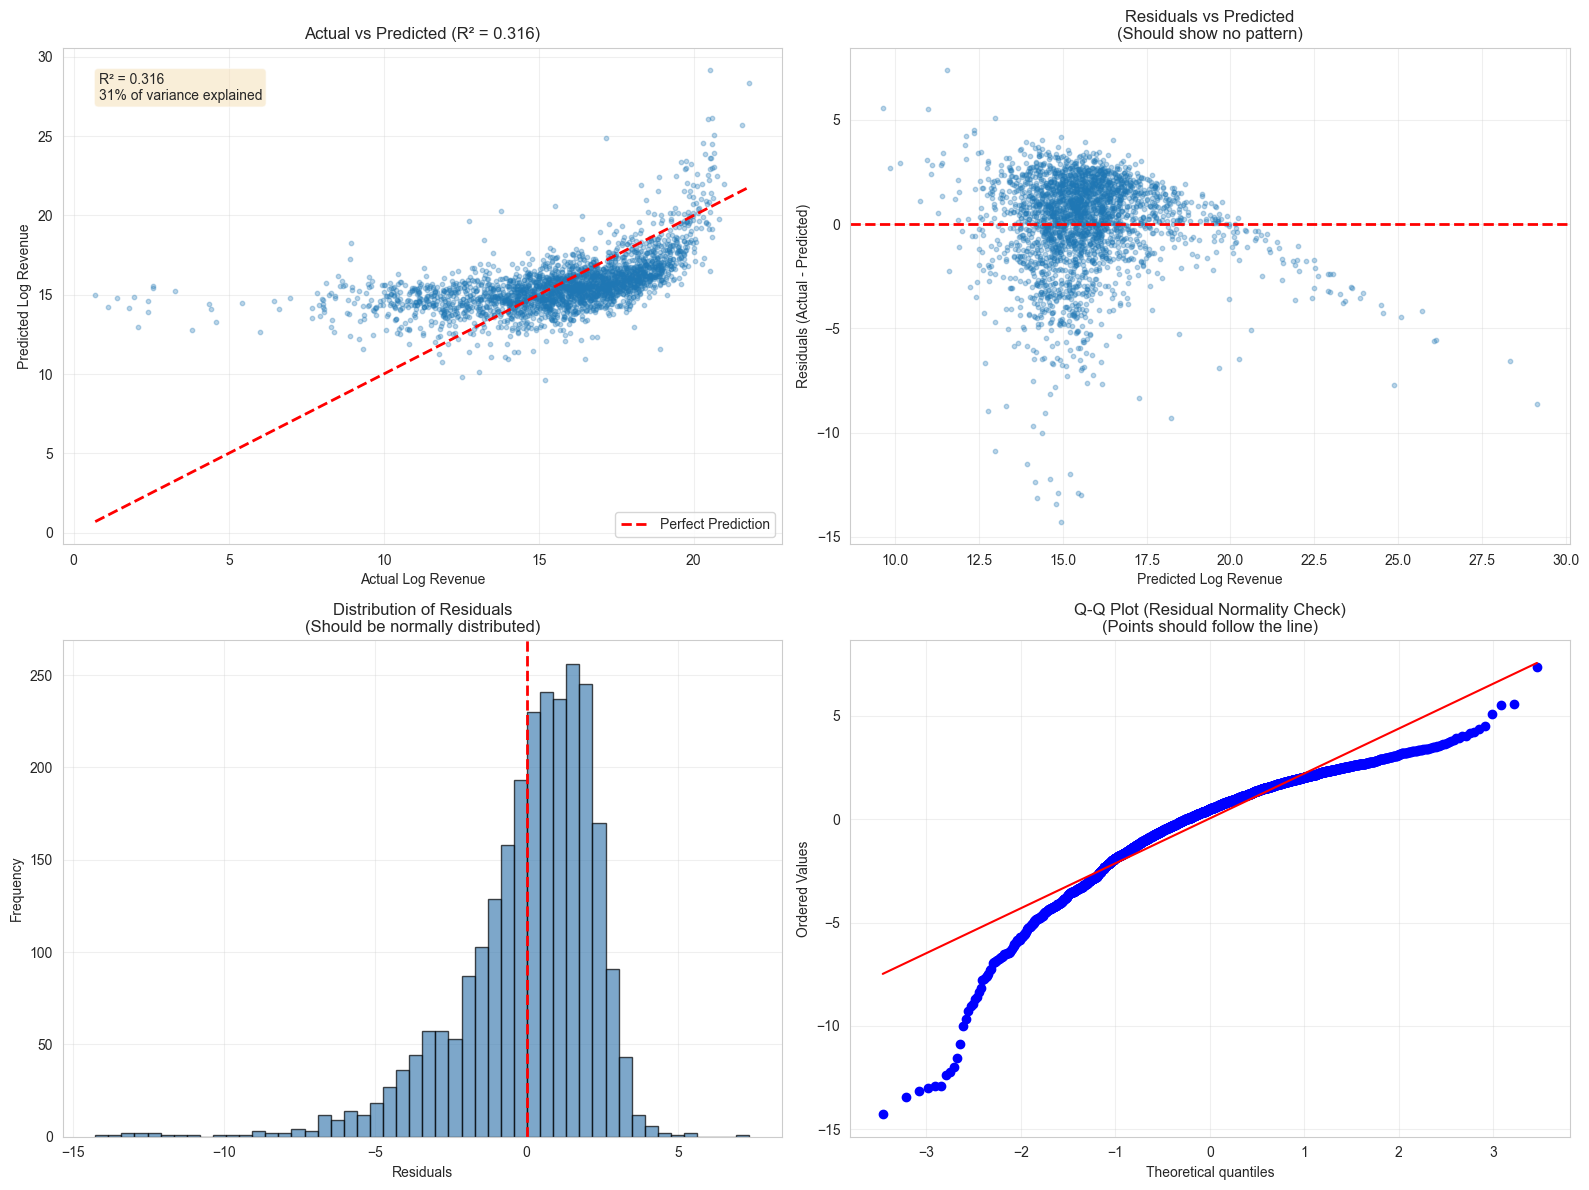


=== REGRESSION DIAGNOSTICS ===

Residual Statistics:
  Mean: 0.0355 (should be ~0)
  Std Dev: 2.2872
  Skewness: -1.5464 (0 = normal)

=== MODEL PERFORMANCE ===
R² = 0.316: The model explains 31.6% of the variance in log(revenue)
RMSE = 2.287: Average prediction error in log(revenue) units

Interpretation:
  • R² of 0.316 indicates moderate predictive power
  • The model captures key relationships but other factors also influence revenue
  • Residual plots help assess model assumptions and identify potential improvements


In [77]:
# Load preprocessed data from regression_pipeline.ipynb
df_preprocessed = pd.read_csv('movies_regression_ready.csv')
print(f"Loaded preprocessed data shape: {df_preprocessed.shape}")

# Filter to movies with financial data (same filter as before)
df_preprocessed = df_preprocessed[df_preprocessed['revenue'].notna() & 
                                  (df_preprocessed['revenue'] > 0)].copy()

# Identify feature columns (all columns except target variables)
target_cols = ['revenue', 'budget', 'financial_success']
feature_cols = [col for col in df_preprocessed.columns if col not in target_cols]

print(f"\nPreprocessed features ({len(feature_cols)}): {feature_cols[:10]}...")  # Show first 10
print(f"Target variables: {[col for col in target_cols if col in df_preprocessed.columns]}")

# Extract preprocessed features (already encoded and scaled)
X_scaled = df_preprocessed[feature_cols].values

# Target: log-transformed revenue
y = np.log1p(df_preprocessed['revenue'])

# Remove rows with missing target
valid_idx = y.notna()
X_scaled = X_scaled[valid_idx]
y = y[valid_idx]

print(f"\nFinal dataset for regression:")
print(f"  Features shape: {X_scaled.shape}")
print(f"  Target shape: {y.shape}")

# Train model
model_revenue = LinearRegression()
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model_revenue.fit(X_train, y_train)

# Predictions
y_pred = model_revenue.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Linear Regression on Log-Revenue:")
print(f"  R²: {r2:.4f}")
print(f"  RMSE: {rmse:.4f}")

# Feature importance (coefficients)
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model_revenue.coef_
}).sort_values('coefficient', key=abs, ascending=False)

# Filter to show only meaningful features (exclude rare country/language categories)
# Focus on main numerical features and common genres
main_features = []
for feat in feature_cols:
    if feat in ['budget', 'runtime', 'vote_count', 'vote_average', 'vote_reliability', 
                'popularity', 'is_summer', 'release_year']:
        main_features.append(feat)
    elif feat.startswith('primary_genre_'):
        main_features.append(feat)

feature_importance_filtered = feature_importance[feature_importance['feature'].isin(main_features)]

print(f"\nTop 15 Most Important Features (by absolute coefficient):")
print(feature_importance.head(15).to_string(index=False))

print(f"\n=== INTERPRETATION OF FEATURE IMPORTANCE ===")
print(f"\nWhat do these coefficients mean?")
print(f"Since features are standardized (scaled), coefficients show:")
print(f"  • Positive coefficient: Feature increases log(revenue)")
print(f"  • Negative coefficient: Feature decreases log(revenue)")
print(f"  • Larger absolute value = stronger effect")
print(f"\nExample: If 'budget' coefficient = 0.75, then:")
print(f"  A 1 standard deviation increase in budget → 0.75 increase in log(revenue)")
print(f"  This translates to approximately {np.exp(0.75)-1:.1%} increase in revenue")

# Visualize feature importance - focus on main features
top_main_features = feature_importance_filtered.head(15)
plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in top_main_features['coefficient']]
top_main_features.plot(x='feature', y='coefficient', kind='barh', color=colors)
plt.title('Feature Importance in Revenue Prediction\n(Main Features Only)')
plt.xlabel('Coefficient (Standardized Features → Impact on Log Revenue)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# Also show all top features (including rare categories)
top_all_features = feature_importance.head(20)
plt.figure(figsize=(12, 10))
colors = ['green' if x > 0 else 'red' for x in top_all_features['coefficient']]
top_all_features.plot(x='feature', y='coefficient', kind='barh', color=colors)
plt.title('Top 20 Features by Absolute Coefficient\n(All Features)')
plt.xlabel('Coefficient (Impact on Log Revenue)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# Regression diagnostic plots
from scipy import stats as scipy_stats

residuals = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted scatter plot
axes[0, 0].scatter(y_test, y_pred, alpha=0.3, s=10)
axes[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Log Revenue')
axes[0, 0].set_ylabel('Predicted Log Revenue')
axes[0, 0].set_title(f'Actual vs Predicted (R² = {r2:.3f})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Add text with interpretation
axes[0, 0].text(0.05, 0.95, f'R² = {r2:.3f}\n{int(r2*100)}% of variance explained', 
                transform=axes[0, 0].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Residuals vs Predicted
axes[0, 1].scatter(y_pred, residuals, alpha=0.3, s=10)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Log Revenue')
axes[0, 1].set_ylabel('Residuals (Actual - Predicted)')
axes[0, 1].set_title('Residuals vs Predicted\n(Should show no pattern)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals distribution (histogram)
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals\n(Should be normally distributed)')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3)

# 4. Q-Q plot for residual normality
scipy_stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Residual Normality Check)\n(Points should follow the line)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual statistics
print(f"\n=== REGRESSION DIAGNOSTICS ===")
print(f"\nResidual Statistics:")
print(f"  Mean: {residuals.mean():.4f} (should be ~0)")
print(f"  Std Dev: {residuals.std():.4f}")
print(f"  Skewness: {scipy_stats.skew(residuals):.4f} (0 = normal)")

# Model performance interpretation
print(f"\n=== MODEL PERFORMANCE ===")
print(f"R² = {r2:.3f}: The model explains {r2*100:.1f}% of the variance in log(revenue)")
print(f"RMSE = {rmse:.3f}: Average prediction error in log(revenue) units")
print(f"\nInterpretation:")
print(f"  • R² of {r2:.3f} indicates {'moderate' if 0.3 < r2 < 0.7 else 'strong' if r2 > 0.7 else 'weak'} predictive power")
print(f"  • The model captures key relationships but other factors also influence revenue")
print(f"  • Residual plots help assess model assumptions and identify potential improvements")

#### 4.8.2 Logistic Regression for Financial Success

**Purpose:**
- Model probability of financial success.

**Target variable:**
- Financial success (`revenue > 2 × budget`)

**Note:** Uses the same preprocessed features as linear regression.

**Interpretation focus:**
- Odds ratios
- Key drivers increasing success probability


Logistic regression dataset:
  Features shape: (12868, 291)
  Target shape: (12868,)
  Financial success rate: 32.3%
Logistic Regression for Financial Success:
  Accuracy: 0.7700

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.92      0.84      1726
           1       0.74      0.47      0.57       848

    accuracy                           0.77      2574
   macro avg       0.76      0.69      0.71      2574
weighted avg       0.76      0.77      0.75      2574


Top 15 Features for Financial Success (by Odds Ratio):
                                 feature  coefficient  odds_ratio
                    original_language_te     1.520914    4.576407
                    original_language_kn     1.440833    4.224213
                    original_language_ta     1.088415    2.969563
                   primary_country_India     1.073476    2.925530
                    original_language_ml     1.049024    2.854863
                pr

<Figure size 1200x800 with 0 Axes>

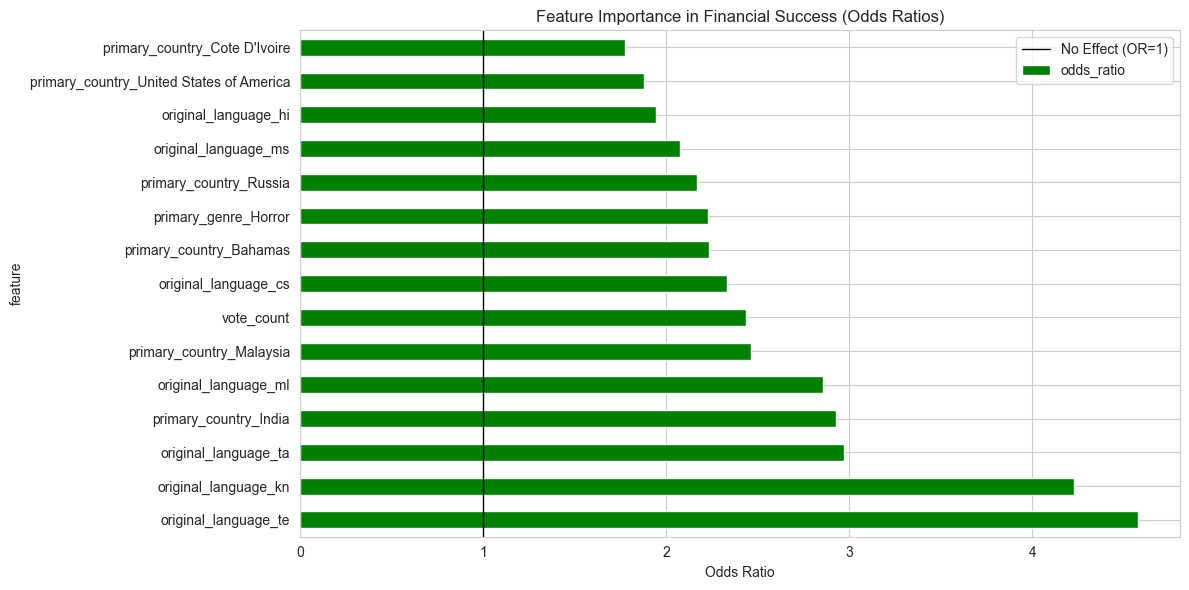

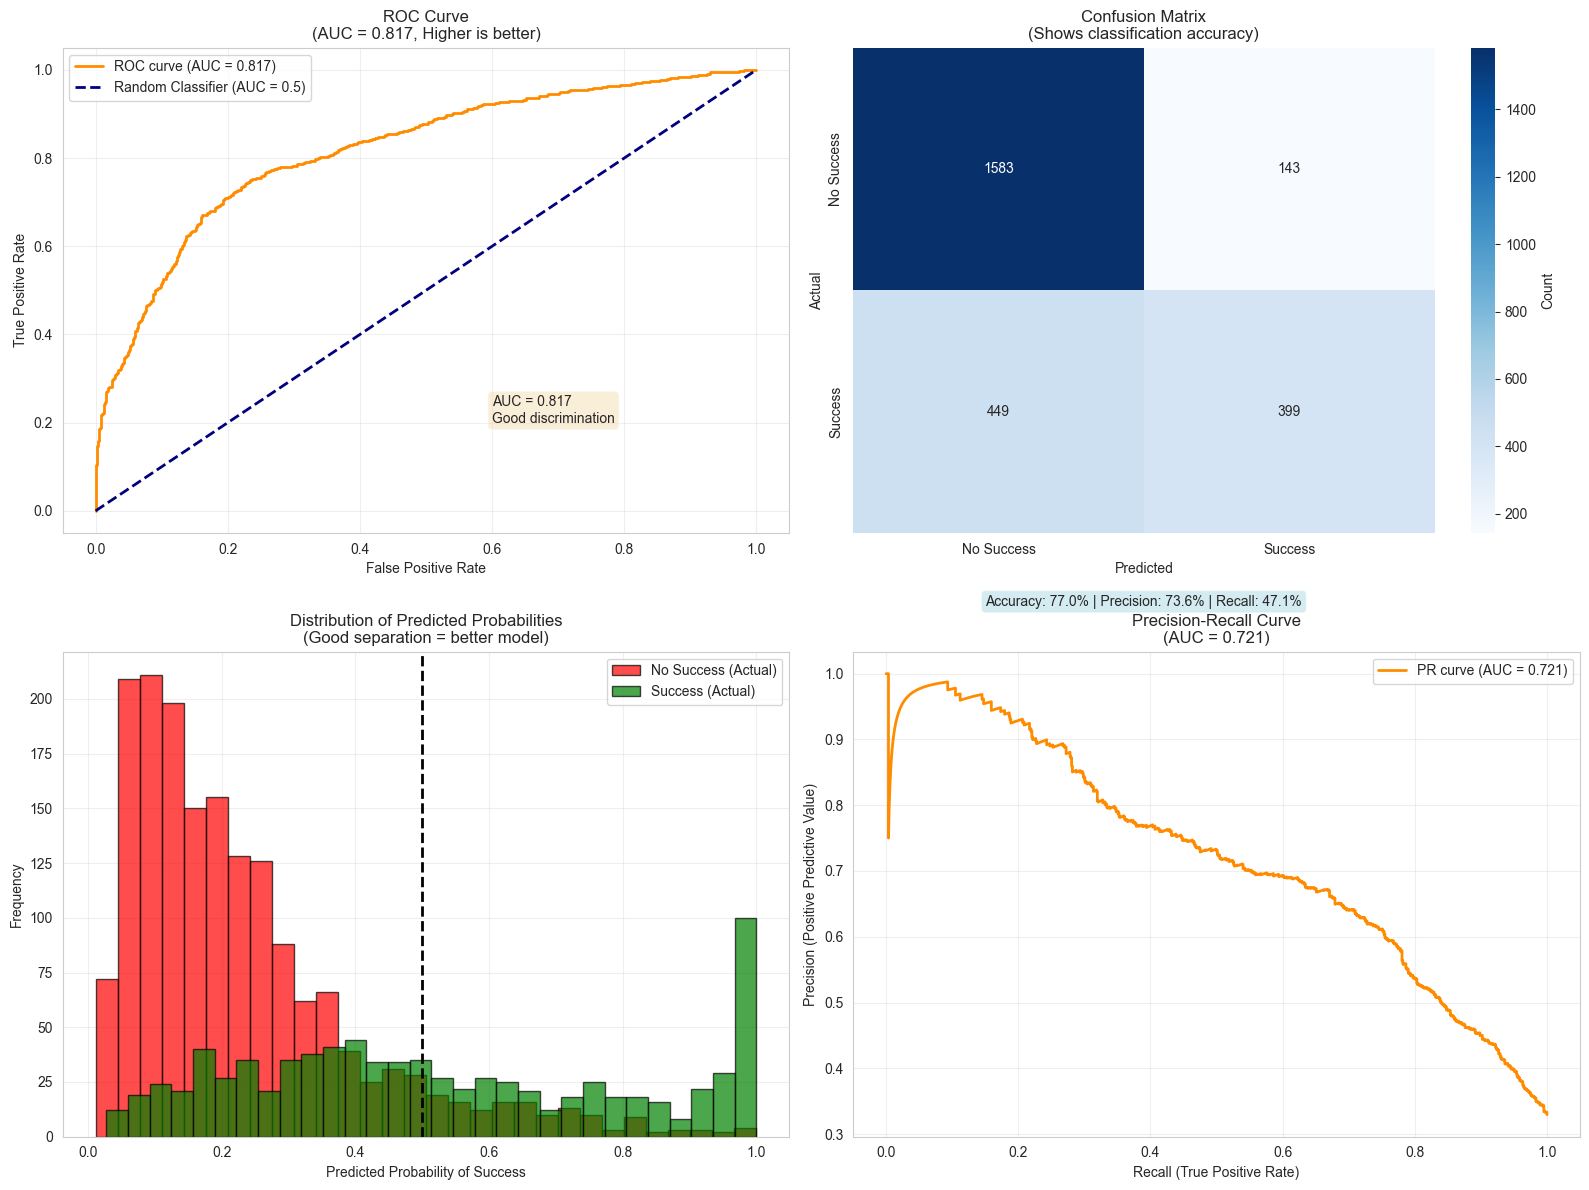


=== LOGISTIC REGRESSION PERFORMANCE ===

Classification Metrics:
  Accuracy: 0.770 (77.0% of predictions are correct)
  ROC AUC: 0.817 (Good discrimination ability)

Confusion Matrix Breakdown:
  True Positives (Correctly predicted success): 399 (15.5%)
  True Negatives (Correctly predicted no success): 1583 (61.5%)
  False Positives (Predicted success but actually failed): 143 (5.6%)
  False Negatives (Predicted failure but actually succeeded): 449 (17.4%)

Interpretation:
  • The model can predict financial success with 77.0% accuracy
  • ROC AUC of 0.817 indicates strong ability to distinguish successful from unsuccessful movies
  • Precision: When the model predicts success, it's correct 73.6% of the time
  • Recall: The model catches 47.1% of all successful movies
  • ROC AUC > 0.7 indicates good discrimination ability


In [78]:
# Use the same preprocessed data (already loaded in previous cell)
# Calculate financial_success target if not already in the preprocessed data
if 'financial_success' in df_preprocessed.columns:
    y_logistic = df_preprocessed['financial_success'].astype(int)
else:
    # Calculate financial_success: revenue > 2 × budget
    y_logistic = (df_preprocessed['revenue'] > 2 * df_preprocessed['budget']).astype(int)

# Use the same preprocessed features (already encoded and scaled)
X_logistic_scaled = df_preprocessed[feature_cols].values

# Remove rows with missing target
valid_idx_logistic = y_logistic.notna()
X_logistic_scaled = X_logistic_scaled[valid_idx_logistic]
y_logistic = y_logistic[valid_idx_logistic]

print(f"Logistic regression dataset:")
print(f"  Features shape: {X_logistic_scaled.shape}")
print(f"  Target shape: {y_logistic.shape}")
print(f"  Financial success rate: {y_logistic.mean()*100:.1f}%")

# Train logistic regression model
model_logistic = LogisticRegression(max_iter=1000, random_state=42)
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_logistic_scaled, y_logistic, test_size=0.2, random_state=42)

model_logistic.fit(X_train, y_train)

# Predictions
y_pred_logistic = model_logistic.predict(X_test)
y_pred_proba = model_logistic.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression for Financial Success:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

# Feature importance (odds ratios)
logistic_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model_logistic.coef_[0],
    'odds_ratio': np.exp(model_logistic.coef_[0])
}).sort_values('odds_ratio', key=abs, ascending=False)

print(f"\nTop 15 Features for Financial Success (by Odds Ratio):")
print(logistic_importance.head(15).to_string(index=False))

# Visualize odds ratios
top_logistic_features = logistic_importance.head(15)
plt.figure(figsize=(12, 8))
colors = ['green' if x > 1 else 'red' for x in top_logistic_features['odds_ratio']]
top_logistic_features.plot(x='feature', y='odds_ratio', kind='barh', color=colors)
plt.title('Feature Importance in Financial Success (Odds Ratios)')
plt.xlabel('Odds Ratio')
plt.axvline(x=1, color='black', linestyle='-', linewidth=1, label='No Effect (OR=1)')
plt.legend()
plt.tight_layout()
plt.show()

# Logistic regression diagnostic plots
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_recall_curve

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
axes[0, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title(f'ROC Curve\n(AUC = {roc_auc:.3f}, Higher is better)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
# Add interpretation text
axes[0, 0].text(0.6, 0.2, f'AUC = {roc_auc:.3f}\n{"Excellent" if roc_auc > 0.9 else "Good" if roc_auc > 0.8 else "Fair" if roc_auc > 0.7 else "Poor"} discrimination', 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Confusion Matrix (heatmap)
cm = confusion_matrix(y_test, y_pred_logistic)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], 
            xticklabels=['No Success', 'Success'], 
            yticklabels=['No Success', 'Success'],
            cbar_kws={'label': 'Count'})
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')
axes[0, 1].set_title('Confusion Matrix\n(Shows classification accuracy)')

# Calculate percentages for interpretation
total = cm.sum()
tn, fp, fn, tp = cm.ravel()
axes[0, 1].text(0.5, -0.15, f'Accuracy: {accuracy:.1%} | Precision: {tp/(tp+fp):.1%} | Recall: {tp/(tp+fn):.1%}', 
                transform=axes[0, 1].transAxes, ha='center',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# 3. Predicted Probability Distribution
axes[1, 0].hist(y_pred_proba[y_test == 0], bins=30, alpha=0.7, label='No Success (Actual)', color='red', edgecolor='black')
axes[1, 0].hist(y_pred_proba[y_test == 1], bins=30, alpha=0.7, label='Success (Actual)', color='green', edgecolor='black')
axes[1, 0].set_xlabel('Predicted Probability of Success')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Predicted Probabilities\n(Good separation = better model)')
axes[1, 0].legend()
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
axes[1, 1].plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
axes[1, 1].set_xlabel('Recall (True Positive Rate)')
axes[1, 1].set_ylabel('Precision (Positive Predictive Value)')
axes[1, 1].set_title(f'Precision-Recall Curve\n(AUC = {pr_auc:.3f})')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model performance interpretation
print(f"\n=== LOGISTIC REGRESSION PERFORMANCE ===")
print(f"\nClassification Metrics:")
print(f"  Accuracy: {accuracy:.3f} ({accuracy*100:.1f}% of predictions are correct)")
print(f"  ROC AUC: {roc_auc:.3f} ({'Excellent' if roc_auc > 0.9 else 'Good' if roc_auc > 0.8 else 'Fair' if roc_auc > 0.7 else 'Poor'} discrimination ability)")

print(f"\nConfusion Matrix Breakdown:")
print(f"  True Positives (Correctly predicted success): {cm[1, 1]} ({cm[1,1]/total*100:.1f}%)")
print(f"  True Negatives (Correctly predicted no success): {cm[0, 0]} ({cm[0,0]/total*100:.1f}%)")
print(f"  False Positives (Predicted success but actually failed): {cm[0, 1]} ({cm[0,1]/total*100:.1f}%)")
print(f"  False Negatives (Predicted failure but actually succeeded): {cm[1, 0]} ({cm[1,0]/total*100:.1f}%)")

print(f"\nInterpretation:")
print(f"  • The model can predict financial success with {accuracy*100:.1f}% accuracy")
print(f"  • ROC AUC of {roc_auc:.3f} indicates {'strong' if roc_auc > 0.8 else 'moderate'} ability to distinguish successful from unsuccessful movies")
print(f"  • Precision: When the model predicts success, it's correct {tp/(tp+fp)*100:.1f}% of the time")
print(f"  • Recall: The model catches {tp/(tp+fn)*100:.1f}% of all successful movies")
print(f"  • ROC AUC > 0.7 indicates good discrimination ability")

### 4.9 Step 7: Key Takeaways for Movie Production

This notebook supports conclusions such as:
- Higher budgets increase revenue potential but raise financial risk.
- Popularity and visibility are stronger drivers than ratings alone.
- Strategic release timing significantly improves outcomes.
- Genre success depends on alignment with contemporary trends.
- Successful movie production combines financial, temporal, and audience factors.


In [79]:
print("="*80)
print("KEY TAKEAWAYS FOR A SUCCESFUL MOVIE PRODUCTION")
print("="*80)

print("\n1. BUDGET STRATEGY")
print("-" * 80)
print("  • Higher budgets are strongly associated with higher revenue (Pearson r ≈ 0.74), but show no meaningful linear relationship with ROI, indicating increased financial risk rather than guaranteed efficiency.")
print("  • Revenue increases with budget, but not proportionally (diminishing returns)")
print("  • Many mid-budget films achieve higher ROI than large-budget films")
print("  • Financial efficiency often peaks at moderate budget levels")

print("\n2. AUDIENCE ENGAGEMENT")
print("-" * 80)
print("  • Longer movies tend to receive higher audience ratings, although this does not necessarily translate into increased popularity or revenue, suggesting that runtime primarily affects perceived quality rather than commercial success.")
print("  • Popularity is a stronger driver of revenue than ratings alone")
print("  • Broad audience attention is more important than critical reception alone")
print("  • Vote reliability is more informative than vote average")

print("\n3. RELEASE TIMING")
print("-" * 80)
print("  • Seasonal timing significantly influences financial performance")
print("  • Summer releases generate higher revenue")
print("  • Industry scale and financial stakes have increased significantly in recent decades")

print("\n4. GENRE STRATEGY")
print("-" * 80)
print("  • Blockbuster genres such as Action and Adventure dominate total revenue, while genres such as Horror and Documentary achieve higher median ROI, indicating lower-risk, higher-efficiency production strategies.")
print("  • Genre popularity and production focus evolve over time")
print("  • Growth of Action, Adventure, and Sci-Fi in modern decades")

print("\n5. PRODUCTION COMPANIES")
print("-" * 80)
print("  • Large studios tend to follow a high-budget, high-reward strategy with consistent outcomes, while smaller studios exhibit greater variance but occasionally achieve high ROI through lower-budget productions.")

print("\n6. REGRESSION INSIGHTS")
print("-" * 80)
print("  • Multiple factors combine to influence revenue (budget, popularity, runtime, genre)")
print("  • Financial success probability can be modeled using key production factors")
print("  • Strategic production decisions significantly impact success outcomes")

KEY TAKEAWAYS FOR A SUCCESFUL MOVIE PRODUCTION

1. BUDGET STRATEGY
--------------------------------------------------------------------------------
  • Higher budgets are strongly associated with higher revenue (Pearson r ≈ 0.74), but show no meaningful linear relationship with ROI, indicating increased financial risk rather than guaranteed efficiency.
  • Revenue increases with budget, but not proportionally (diminishing returns)
  • Many mid-budget films achieve higher ROI than large-budget films
  • Financial efficiency often peaks at moderate budget levels

2. AUDIENCE ENGAGEMENT
--------------------------------------------------------------------------------
  • Longer movies tend to receive higher audience ratings, although this does not necessarily translate into increased popularity or revenue, suggesting that runtime primarily affects perceived quality rather than commercial success.
  • Popularity is a stronger driver of revenue than ratings alone
  • Broad audience attention